In [1]:
# Imports for the interval propagation and physical bank control notebook

import json
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import List

import constants
import AtmosphereModel
import control
import ReactionControl

from interval_math import Interval, promote
from math_3d import (
    IntervalSupervisorConfig,
    annotate_nominal_state_with_interval_supervisor,
    f_interval,
    nominal_state_to_interval_box,
    nominal_aero_forces_from_state,
    nominal_eom_step,
    nominal_heating_envelope_from_state,
)

from control import (
    ReentryState,
    GuidanceScheduler,
    SimpleBankGuidance,
    BasicObservationProvider,
    BankActuatorLimits,
    BankActuator,
    RollTorqueController,
    CapsuleControlConfig,
    CapsuleControlStack,
    wrap_to_pi,
)

from ReactionControl import (
    build_orion_cm_rcs_12,
)


## helper functions for plotting the interval stuff

In [2]:
# Helper functions for readable logging, plotting, and milestone 1 roll updates

STATE_NAMES = ["r_m", "phi_rad", "lam_rad", "V_mps", "gamma_rad", "chi_rad"]


def interval_mid(iv):
    # Returns the midpoint of an interval
    return 0.5 * (iv.lo + iv.hi)


def interval_width(iv):
    # returns the width of an interval
    return iv.hi - iv.lo


def box_mid(box):
    # Return midpoints for every interval in the box
    return [interval_mid(iv) for iv in box]


def box_widths(box):
    # Return the widths for every interval in the box
    return [interval_width(iv) for iv in box]


def deg(x_rad):
    # Convert from radians to degrees
    return math.degrees(x_rad)


def alt_from_r(r_m):
    # Convert radius from Earth center into geometric altitude
    return r_m - constants.RADIUS_EARTH

def wrap_angle_rad(x_rad):
    # Wrap an angle into the principal range
    return wrap_to_pi(float(x_rad))


def atmosphere_from_state_vector(x):
    # Read radius and speed from the translational state vector
    r_m, _, _, V_mps, _, _ = x

    # Convert radius into altitude for the atmosphere model
    alt_m = max(0.0, alt_from_r(r_m))

    # Query the nominal atmosphere at this altitude
    atm = AtmosphereModel.US_Standard_ATM(alt_m)

    # Use zero density if the atmosphere model returns None above its range
    rho = atm["rho_kgm3"] if atm["rho_kgm3"] is not None else 0.0
    T_K = atm["T_K"] if atm["T_K"] is not None else np.nan
    p_Pa = atm["p_Pa"] if atm["p_Pa"] is not None else np.nan

    # Compute dynamic pressure from density and speed
    q_pa = 0.5 * rho * V_mps * V_mps

    # Return a compact telemetry dictionary
    return {
        "alt_m": alt_m,
        "rho_kgm3": rho,
        "T_K": T_K,
        "p_Pa": p_Pa,
        "q_pa": q_pa,
    }


def milestone1_roll_update(
    sigma_actual_rad,
    roll_rate_rad_s,
    tau_rcs_z_Nm,
    dt_s,
    Izz_kgm2,
):
    # Convert applied roll torque into roll angular acceleration
    roll_accel_rad_s2 = float(tau_rcs_z_Nm) / float(Izz_kgm2)

    # Integrate roll rate forward one time step
    roll_rate_next_rad_s = float(roll_rate_rad_s) + roll_accel_rad_s2 * float(dt_s)

    # Integrate actual bank angle using the updated roll rate
    sigma_actual_next_rad = wrap_angle_rad(
        float(sigma_actual_rad) + roll_rate_next_rad_s * float(dt_s)
    )

    # Return the new roll state for this step
    return {
        "roll_accel_rad_s2": roll_accel_rad_s2,
        "roll_rate_next_rad_s": roll_rate_next_rad_s,
        "sigma_actual_next_rad": sigma_actual_next_rad,
    }

## set how far the sim looks ahead at each time step to decide the bank angle
### PREDICTOR_CORRECTOR_HORIZON_STEPS = 120 means 120/4 = 30s, so it looks 30 seconds ahead each step 

In [3]:
import constants
import importlib

print(constants.__file__)
print(hasattr(constants, "PREDICTOR_CORRECTOR_HORIZON_STEPS"))

importlib.reload(constants)

print(constants.__file__)
print(hasattr(constants, "PREDICTOR_CORRECTOR_HORIZON_STEPS"))
print(constants.PREDICTOR_CORRECTOR_HORIZON_STEPS)

c:\Users\Risha\Desktop\ReEntryAI\StochasticEntrySim\constants.py
True
c:\Users\Risha\Desktop\ReEntryAI\StochasticEntrySim\constants.py
True
40


In [4]:
# Vehicle aerodynamic control and reaction control system setup used by the notebook

# Define the physical and aerodynamic properties of the capsule
params = {
    "mass_kg": float(constants.CAPSULE_MASS_KG),
    "ref_area_m2": float(constants.CAPSULE_REFERENCE_AREA_M2),
    "aero_model": "scheduled_orion_like",
    "CD_const": 1.15,
    "CL_const": 0.28,
}

# Define the simulation time step and total duration
dt_s = float(constants.ENTRY_DT_S)
t_final_s = 1000.0
num_steps = int(t_final_s / dt_s)

# Define the moment of inertia for the roll axis
Izz_kgm2 = float(constants.CAPSULE_IZZ_KGM2)

# Define the landing target latitude and longitude in radians
target_phi_rad = math.radians(15.00)
target_lam_rad = math.radians(15.00)

# Configure the guidance loop and scheduler
control_cfg = CapsuleControlConfig(
    guidance_period_s=float(constants.GUIDANCE_PERIOD_S),
)

guidance_scheduler = GuidanceScheduler(
    period_s=float(constants.GUIDANCE_PERIOD_S),
)

# Setup the heat aware short horizon predictor corrector guidance
# This still returns sigma_cmd only
# The downstream bank actuator and RCS roll chain remain unchanged
guidance_law = SimpleBankGuidance(
    target_phi_rad=float(target_phi_rad),
    target_lam_rad=float(target_lam_rad),
    params=dict(params),
    max_bank_deg=70.0,
    min_bank_deg=40.0,
    downrange_gain=1e-6,
    velocity_enable_mps=40_000.0,
    predictor_horizon_steps=int(constants.PREDICTOR_CORRECTOR_HORIZON_STEPS),
    prediction_dt_s=float(constants.ENTRY_DT_S),
    candidate_bank_deg=[float(v) for v in constants.PREDICTOR_CANDIDATE_BANK_DEG],
    weight_range=float(constants.PREDICTOR_COST_WEIGHT_RANGE),
    weight_heading=float(constants.PREDICTOR_COST_WEIGHT_HEADING),
    weight_cross_track=float(constants.PREDICTOR_COST_WEIGHT_CROSS_TRACK),
    weight_heat=float(constants.PREDICTOR_COST_WEIGHT_HEAT),
    heat_rate_limit=float(constants.HEAT_RATE_LIMIT_DEFAULT),
    heat_load_limit=float(constants.HEAT_LOAD_LIMIT_DEFAULT),
    infeasible_penalty=float(constants.PREDICTOR_HEAT_INFEASIBLE_PENALTY),
    invalid_interval_penalty=float(constants.PREDICTOR_INVALID_INTERVAL_PENALTY),
    include_zero_bank_candidate=True,
)

# Provide the observation model with the landing targets and capsule parameters
observation_provider = BasicObservationProvider(
    target_phi_rad=target_phi_rad,
    target_lam_rad=target_lam_rad,
    params=params,
)

# Define the physical limits for the bank actuator
bank_actuator = BankActuator(
    BankActuatorLimits(
        sigma_rate_max_rps=math.radians(20.0),
        sigma_accel_max_rps2=math.radians(40.0),
    )
)

# Tune the proportional derivative roll torque controller
roll_controller = RollTorqueController(
    kp_Nm_per_rad=float(constants.ROLL_KP_NM_PER_RAD),
    kd_Nm_per_rad_s=float(constants.ROLL_KD_NM_PER_RAD_S),
    max_torque_Nm=float(constants.ROLL_CMD_MAX_TORQUE_NM),
    sigma_deadband_rad=float(constants.ROLL_SIGMA_DEADBAND_RAD),
    rate_deadband_rad_s=float(constants.ROLL_RATE_DEADBAND_RAD_S),
)

# Assemble the full capsule control stack combining guidance and physical controllers
capsule_control = CapsuleControlStack(
    cfg=control_cfg,
    scheduler=guidance_scheduler,
    guidance=guidance_law,
    obs_provider=observation_provider,
    bank_actuator=bank_actuator,
    roll_controller=roll_controller,
)

# Initialize the reaction control system for the capsule
rcs_system = build_orion_cm_rcs_12()

# Configure the interval supervisor with uncertainty widths and fallback tuning
supervisor_cfg = IntervalSupervisorConfig(
    r_half_width_m=10.0,
    phi_half_width_rad=math.radians(0.01),
    lam_half_width_rad=math.radians(0.01),
    V_half_width_mps=20.0,
    gamma_half_width_rad=math.radians(0.15),
    chi_half_width_rad=math.radians(0.20),
    min_altitude_m=0.0,
    max_altitude_m=130_000.0,
    max_speed_mps=80_000.0,
    max_dynamic_pressure_pa=5.0e7,
    include_heating=True,
    heat_rate_limit=float(constants.HEAT_RATE_LIMIT_DEFAULT),
    heat_load_limit=float(constants.HEAT_LOAD_LIMIT_DEFAULT),
    interval_recenter_enabled=bool(constants.INTERVAL_RECENTER_ENABLED),
    interval_recenter_cadence_s=float(constants.INTERVAL_RECENTER_CADENCE_S),
    interval_recenter_width_thresholds=dict(constants.INTERVAL_RECENTER_WIDTH_THRESHOLDS),
    interval_box_split_enabled=bool(constants.INTERVAL_BOX_SPLIT_ENABLED),
    interval_box_split_max_depth=int(constants.INTERVAL_BOX_SPLIT_MAX_DEPTH),
    interval_box_split_width_thresholds=dict(constants.INTERVAL_BOX_SPLIT_WIDTH_THRESHOLDS),
    interval_denominator_safety_V_mps=float(constants.INTERVAL_DENOMINATOR_SAFETY_V_MPS),
    interval_denominator_safety_cos_gamma=float(constants.INTERVAL_DENOMINATOR_SAFETY_COS_GAMMA),
    interval_denominator_safety_cos_phi=float(constants.INTERVAL_DENOMINATOR_SAFETY_COS_PHI),
)

# Reset the control stack and reaction control system to their initial states
capsule_control.reset()
rcs_system.reset()

# Output a summary dictionary of the configuration
{
    "params": params,
    "dt_s": dt_s,
    "t_final_s": t_final_s,
    "num_steps": num_steps,
    "Izz_kgm2": Izz_kgm2,
    "guidance_period_s": constants.GUIDANCE_PERIOD_S,
    "predictor_horizon_steps": int(constants.PREDICTOR_CORRECTOR_HORIZON_STEPS),
    "predictor_candidate_bank_deg": list(constants.PREDICTOR_CANDIDATE_BANK_DEG),
    "heat_rate_limit": float(constants.HEAT_RATE_LIMIT_DEFAULT),
    "heat_load_limit": float(constants.HEAT_LOAD_LIMIT_DEFAULT),
    "interval_recenter_enabled": bool(constants.INTERVAL_RECENTER_ENABLED),
    "interval_recenter_cadence_s": float(constants.INTERVAL_RECENTER_CADENCE_S),
    "interval_box_split_enabled": bool(constants.INTERVAL_BOX_SPLIT_ENABLED),
    "interval_box_split_max_depth": int(constants.INTERVAL_BOX_SPLIT_MAX_DEPTH),
    "roll_pos_thrusters": rcs_system.roll_pos_names,
    "roll_neg_thrusters": rcs_system.roll_neg_names,
}


{'params': {'mass_kg': 8500.0,
  'ref_area_m2': 19.634954084936208,
  'aero_model': 'scheduled_orion_like',
  'CD_const': 1.15,
  'CL_const': 0.28},
 'dt_s': 0.25,
 't_final_s': 1000.0,
 'num_steps': 4000,
 'Izz_kgm2': 20000.0,
 'guidance_period_s': 1.0,
 'predictor_horizon_steps': 40,
 'predictor_candidate_bank_deg': [20.0,
  25.0,
  30.0,
  35.0,
  40.0,
  45.0,
  50.0,
  55.0,
  60.0,
  65.0,
  70.0],
 'heat_rate_limit': 15000000.0,
 'heat_load_limit': 2500000000.0,
 'interval_recenter_enabled': True,
 'interval_recenter_cadence_s': 5.0,
 'interval_box_split_enabled': True,
 'interval_box_split_max_depth': 2,
 'roll_pos_thrusters': ['POD0_RPOS', 'POD1_RPOS', 'POD2_RPOS', 'POD3_RPOS'],
 'roll_neg_thrusters': ['POD0_RNEG', 'POD1_RNEG', 'POD2_RNEG', 'POD3_RNEG']}

In [5]:
# Initial nominal translational and roll state

# State order
# r
# phi
# lam
# V
# gamma
# chi

# Define the starting conditions for the spacecraft trajectory
x_nominal = [
    constants.RADIUS_EARTH + 300_000.0,
    math.radians(0.0),
    math.radians(0.0),
    7500.0,
    math.radians(-5.5),
    math.radians(90.0),
]

# Initialize the starting bank angle and roll rate to zero
sigma_actual_0_rad = 0.0
roll_rate_0_rad_s = 0.0

# Create the control state object using the established initial conditions
state_ctrl = ReentryState(
    r_m=float(x_nominal[0]),
    phi_rad=float(x_nominal[1]),
    lam_rad=float(x_nominal[2]),
    V_mps=float(x_nominal[3]),
    gamma_rad=float(x_nominal[4]),
    chi_rad=float(x_nominal[5]),
    sigma_actual_rad=float(sigma_actual_0_rad),
    roll_rate_rad_s=float(roll_rate_0_rad_s),
    sigma_cmd_rad=0.0,
    sigma_target_rad=0.0,
)

# Clear any previous states in the control and reaction control systems
capsule_control.reset()
rcs_system.reset()

# Output the starting conditions for verification
print("Initial altitude m", alt_from_r(x_nominal[0]))
print("Initial speed m per s", x_nominal[3])
print("Initial gamma deg", deg(x_nominal[4]))
print("Initial chi deg", deg(x_nominal[5]))
print("Initial sigma_actual deg", deg(state_ctrl.sigma_actual_rad))
print("Initial roll_rate deg per s", deg(state_ctrl.roll_rate_rad_s))

Initial altitude m 300000.0
Initial speed m per s 7500.0
Initial gamma deg -5.5
Initial chi deg 90.0
Initial sigma_actual deg 0.0
Initial roll_rate deg per s 0.0


In [6]:
# interval supervisor settings

# these widths define translational state uncertainty only
# the bank angle used by the nominal path remains deterministic
# the interval layer annotates uncertainty around that flown nominal motion

# turn cadence recenter off for rl style data generation
# this keeps recenter tied to interval health rather than fixed time buckets
interval_recenter_use_cadence = False

supervisor_cfg = IntervalSupervisorConfig(
    r_half_width_m=10.0,
    phi_half_width_rad=math.radians(0.01),
    lam_half_width_rad=math.radians(0.01),
    V_half_width_mps=20.0,
    gamma_half_width_rad=math.radians(0.15),
    chi_half_width_rad=math.radians(0.20),
    min_altitude_m=0.0,
    max_altitude_m=130_000.0,
    max_speed_mps=80_000.0,
    max_dynamic_pressure_pa=5.0e7,
    include_heating=True,
    heat_rate_limit=float(constants.HEAT_RATE_LIMIT_DEFAULT),
    heat_load_limit=float(constants.HEAT_LOAD_LIMIT_DEFAULT),
    interval_recenter_enabled=bool(constants.INTERVAL_RECENTER_ENABLED),
    interval_recenter_use_cadence=bool(interval_recenter_use_cadence),
    interval_recenter_cadence_s=float(constants.INTERVAL_RECENTER_CADENCE_S),
    interval_recenter_width_thresholds=dict(constants.INTERVAL_RECENTER_WIDTH_THRESHOLDS),
    interval_box_split_enabled=bool(constants.INTERVAL_BOX_SPLIT_ENABLED),
    interval_box_split_max_depth=int(constants.INTERVAL_BOX_SPLIT_MAX_DEPTH),
    interval_box_split_width_thresholds=dict(constants.INTERVAL_BOX_SPLIT_WIDTH_THRESHOLDS),
    interval_denominator_safety_V_mps=float(constants.INTERVAL_DENOMINATOR_SAFETY_V_MPS),
    interval_denominator_safety_cos_gamma=float(constants.INTERVAL_DENOMINATOR_SAFETY_COS_GAMMA),
    interval_denominator_safety_cos_phi=float(constants.INTERVAL_DENOMINATOR_SAFETY_COS_PHI),
)

x_interval = None

supervisor_cfg

IntervalSupervisorConfig(r_half_width_m=10.0, phi_half_width_rad=0.00017453292519943296, lam_half_width_rad=0.00017453292519943296, V_half_width_mps=20.0, gamma_half_width_rad=0.002617993877991494, chi_half_width_rad=0.003490658503988659, min_altitude_m=0.0, max_altitude_m=130000.0, max_speed_mps=80000.0, max_dynamic_pressure_pa=50000000.0, include_heating=True, heat_rate_limit=15000000.0, heat_load_limit=2500000000.0, interval_recenter_enabled=True, interval_recenter_use_cadence=False, interval_recenter_cadence_s=5.0, interval_recenter_width_thresholds={'r': 2000.0, 'phi': 0.003490658503988659, 'lam': 0.003490658503988659, 'V': 400.0, 'gamma': 0.10471975511965978, 'chi': 0.13962634015954636}, interval_box_split_enabled=True, interval_box_split_max_depth=2, interval_box_split_width_thresholds={'r': 4000.0, 'phi': 0.006108652381980153, 'lam': 0.006108652381980153, 'V': 800.0, 'gamma': 0.13962634015954636, 'chi': 0.20943951023931956}, interval_denominator_safety_V_mps=250.0, interval_den

## Deterministic bank schedule

In [7]:
# Setup objects for the physical closed loop bank control path

# This notebook no longer uses a hand written sigma schedule.
# The nominal path now follows:
# guidance produces sigma_cmd
# bank actuator produces sigma_target
# roll controller produces tau_roll_cmd_Nm
# RCS produces body torque
# roll dynamics produce sigma_actual
# translational dynamics fly sigma_actual

capsule_control.reset()
rcs_system.reset()

trajectory_id = "traj_000"

# This object is carried forward on the live trajectory
# Candidate rollouts clone it so they do not contaminate each other
interval_heat_shield = None

# Store failed heat guidance cycles for later RL teaching
failed_heat_rows = []

# Define output file names once here so later save cells can reuse them
success_trajectory_csv_path = constants.SUCCESS_TRAJECTORY_CSV_DEFAULT
failed_heat_step_csv_path = constants.FAILED_HEAT_STEP_CSV_DEFAULT
failed_heat_episode_csv_path = constants.FAILED_HEAT_EPISODE_CSV_DEFAULT

# Define the failed heat log schema explicitly
# This makes the exported csv stable even if there are zero failed rows
failed_heat_columns = [
    "trajectory_id",
    "step",
    "guidance_cycle_index",
    "time_s",
    "r_m",
    "phi_rad",
    "lam_rad",
    "V_mps",
    "gamma_rad",
    "chi_rad",
    "target_phi_rad",
    "target_lam_rad",
    "sigma_cmd_candidate_deg_json",
    "sigma_cmd_candidate_cost_json",
    "sigma_cmd_candidate_heat_flag_json",
    "sigma_cmd_candidate_failure_reason_json",
    "selected_sigma_cmd_rad",
    "selected_sigma_cmd_deg",
    "sigma_actual_rad",
    "range_to_go_m",
    "heading_error_rad",
    "cross_track_error_m",
    "dynamic_pressure_pa",
    "density_kgm3",
    "predicted_max_heating_rate_lo",
    "predicted_max_heating_rate_hi",
    "predicted_max_heat_load_lo",
    "predicted_max_heat_load_hi",
    "heat_feasible_flag",
    "violation_amount",
    "first_violation_step",
    "first_violation_time_s",
    "failure_reason",
    "interval_propagation_invalid",
    "geometry_cost",
    "heat_penalty",
    "total_cost",
]

# Keep the main log column list readable for inspection
# The DataFrame is still built from row dictionaries in the main loop
log_columns = [
    "step",
    "t_s",
    "guidance_updated",
    "trajectory_id",
    "guidance_cycle_index",
    "sigma_cmd_rad",
    "sigma_target_rad",
    "sigma_actual_rad",
    "roll_rate_rad_s",
    "roll_accel_rad_s2",
    "tau_roll_cmd_Nm",
    "tau_roll_capacity_Nm",
    "requested_duty",
    "fired_this_step",
    "active_thrusters",
    "torque_z_from_rcs",
    "force_x_from_rcs",
    "force_y_from_rcs",
    "force_z_from_rcs",
    "r_m",
    "phi_rad",
    "lam_rad",
    "V_mps",
    "gamma_rad",
    "chi_rad",
    "alt_m",
    "rho_kgm3",
    "q_pa",
    "T_K",
    "p_Pa",
    "drag_mag_N",
    "lift_mag_N",
    "gravity_mps2",
    "range_to_go_m",
    "heading_error_rad",
    "cross_track_error_m",
    "interval_sigma_lo",
    "interval_sigma_hi",
    "interval_rho_lo",
    "interval_rho_hi",
    "interval_q_lo",
    "interval_q_hi",
    "interval_alt_lo",
    "interval_alt_hi",
    "width_r_m",
    "width_phi_rad",
    "width_lam_rad",
    "width_V_mps",
    "width_gamma_rad",
    "width_chi_rad",
    "dx_width_r",
    "dx_width_phi",
    "dx_width_lam",
    "dx_width_V",
    "dx_width_gamma",
    "dx_width_chi",
    "heating_qdot_max_lo",
    "heating_qdot_max_hi",
    "heating_qdot_mean_lo",
    "heating_qdot_mean_hi",
    "heating_Q_max_lo",
    "heating_Q_max_hi",
    "guidance_selected_candidate_index",
    "guidance_any_feasible_candidate",
    "guidance_selected_candidate_heat_feasible",
    "guidance_chosen_sigma_cmd_deg",
    "guidance_chosen_sigma_mag_deg",
    "guidance_heading_deadband_deg",
    "guidance_current_altitude_rate_mps",
    "guidance_selected_geometry_cost",
    "guidance_selected_heat_penalty",
    "guidance_selected_total_cost",
    "guidance_selected_failure_reason",
    "guidance_selected_violation_amount",
    "guidance_selected_first_violation_step",
    "guidance_selected_first_violation_time_s",
    "guidance_selected_max_heating_rate_lo",
    "guidance_selected_max_heating_rate_hi",
    "guidance_selected_max_heat_load_lo",
    "guidance_selected_max_heat_load_hi",
    "guidance_candidate_count",
    "guidance_candidate_sigma_deg_json",
    "guidance_candidate_cost_json",
    "guidance_candidate_heat_flag_json",
    "guidance_candidate_failure_reason_json",
    "safety_status",
    "safety_checks",
    "layer_indices",
]

print("Closed loop setup ready")
print("Guidance period s", float(constants.GUIDANCE_PERIOD_S))
print("Physics dt s", dt_s)
print("Predictor horizon steps", int(constants.PREDICTOR_CORRECTOR_HORIZON_STEPS))
print("Trajectory id", trajectory_id)
print("Positive roll thrusters", rcs_system.roll_pos_names)
print("Negative roll thrusters", rcs_system.roll_neg_names)

Closed loop setup ready
Guidance period s 1.0
Physics dt s 0.25
Predictor horizon steps 40
Trajectory id traj_000
Positive roll thrusters ['POD0_RPOS', 'POD1_RPOS', 'POD2_RPOS', 'POD3_RPOS']
Negative roll thrusters ['POD0_RNEG', 'POD1_RNEG', 'POD2_RNEG', 'POD3_RNEG']


## Nominal translational step using the same interval equations

In [8]:
# Nominal translational step driven by the physically flown sigma_actual

# The nominal translational dynamics are advanced using the actual bank angle
# produced by the guidance chain, roll controller, RCS allocation, and the
# milestone 1 roll state update.
#
# This wrapper stays intentionally small.
# The corrected translational physics live inside nominal_eom_step.

def nominal_step_closed_loop(x_nominal_old, sigma_actual_rad, params, dt_s):
    # Run one nominal Euler step using the corrected shared implementation
    step_info = nominal_eom_step(
        x=x_nominal_old,
        sigma_rad=float(sigma_actual_rad),
        params=params,
        dt_s=float(dt_s),
    )

    # Extract the advanced state and the derivative vector
    x_nominal_new = [float(v) for v in step_info["x_next"]]
    dx_nominal = [float(v) for v in step_info["x_dot"]]

    # Return both the compact outputs and the full step info
    return x_nominal_new, dx_nominal, step_info

In [9]:
# One step check for the interval supervisor under deterministic flown sigma

# This confirms the interval layer uses the actual bank angle from the nominal
# path as a punctual interval input rather than creating a separate control mode.

t0 = 0.0

result0 = annotate_nominal_state_with_interval_supervisor(
    x_nominal_old=x_nominal,
    params=params,
    sigma_actual_after_rad=float(state_ctrl.sigma_actual_rad),
    x_interval_old=None,
    supervisor_cfg=supervisor_cfg,
    dt_s=dt_s,
    heat_shield=None,
    t_s=t0,
)

print("Sigma actual used deg", deg(state_ctrl.sigma_actual_rad))
print("Altitude interval m", result0.altitude_interval)
print("Density interval", result0.rho_interval)
print("Dynamic pressure interval Pa", result0.q_interval)
print("State widths new", result0.state_widths_new)
print("Safety status", result0.safety_status)

Sigma actual used deg 0.0
Altitude interval m Interval(299990.0, 300010.0)
Density interval Interval(2.0351562449172356e-11, 2.0361195368634455e-11)
Dynamic pressure interval Pa Interval(0.0005693390298280865, 0.0005757168712872129)
State widths new {'r': 30.730722403153777, 'phi': 0.00035069982070330805, 'lam': 0.00035102264850686923, 'V': 40.01164698668799, 'gamma': 0.005239071150451163, 'chi': 0.0069813173495028025}
Safety status outside


In [10]:
# ensure the heat shield is active
print(result0.heat_shield)
print(result0.heating_qdot_max_interval)
print(result0.heating_Q_max_interval)

Interval(151.15858545706303, 329.2134147106996)
Interval(37.78964636426576, 82.3033536776749)


In [11]:
# Diagnostic replay for the first 20 physical steps
#
# This version keeps the same high level replay goal
# The main change is that the nominal closed loop step now handles
# the internal RCS substeps automatically
# That avoids calling the timed RCS model with the outer 025 second step

from point_math_3d import make_initial_capsule_attitude, step_closed_loop_milestone1

diag_steps = 20

# Rebuild fresh control and RCS objects so the replay starts from a clean state
guidance_scheduler_diag = GuidanceScheduler(
    period_s=float(constants.GUIDANCE_PERIOD_S),
)

guidance_law_diag = SimpleBankGuidance(
    target_phi_rad=float(target_phi_rad),
    target_lam_rad=float(target_lam_rad),
    params=dict(params),
    max_bank_deg=70.0,
    min_bank_deg=40.0,
    downrange_gain=1e-6,
    velocity_enable_mps=30_000.0,
    predictor_horizon_steps=int(constants.PREDICTOR_CORRECTOR_HORIZON_STEPS),
    prediction_dt_s=float(constants.ENTRY_DT_S),
    candidate_bank_deg=[float(v) for v in constants.PREDICTOR_CANDIDATE_BANK_DEG],
    weight_range=float(constants.PREDICTOR_COST_WEIGHT_RANGE),
    weight_heading=float(constants.PREDICTOR_COST_WEIGHT_HEADING),
    weight_cross_track=float(constants.PREDICTOR_COST_WEIGHT_CROSS_TRACK),
    weight_heat=float(constants.PREDICTOR_COST_WEIGHT_HEAT),
    heat_rate_limit=float(constants.HEAT_RATE_LIMIT_DEFAULT),
    heat_load_limit=float(constants.HEAT_LOAD_LIMIT_DEFAULT),
    infeasible_penalty=float(constants.PREDICTOR_HEAT_INFEASIBLE_PENALTY),
    invalid_interval_penalty=float(constants.PREDICTOR_INVALID_INTERVAL_PENALTY),
    include_zero_bank_candidate=True,
)

observation_provider_diag = BasicObservationProvider(
    target_phi_rad=float(target_phi_rad),
    target_lam_rad=float(target_lam_rad),
    params=dict(params),
)

bank_actuator_diag = BankActuator(
    BankActuatorLimits(
        sigma_rate_max_rps=math.radians(20.0),
        sigma_accel_max_rps2=math.radians(40.0),
    )
)

roll_controller_diag = RollTorqueController(
    kp_Nm_per_rad=float(constants.ROLL_KP_NM_PER_RAD),
    kd_Nm_per_rad_s=float(constants.ROLL_KD_NM_PER_RAD_S),
    max_torque_Nm=float(constants.ROLL_CMD_MAX_TORQUE_NM),
    sigma_deadband_rad=float(constants.ROLL_SIGMA_DEADBAND_RAD),
    rate_deadband_rad_s=float(constants.ROLL_RATE_DEADBAND_RAD_S),
)

capsule_control_diag = CapsuleControlStack(
    cfg=CapsuleControlConfig(
        guidance_period_s=float(constants.GUIDANCE_PERIOD_S),
    ),
    scheduler=guidance_scheduler_diag,
    guidance=guidance_law_diag,
    obs_provider=observation_provider_diag,
    bank_actuator=bank_actuator_diag,
    roll_controller=roll_controller_diag,
)

rcs_system_diag = build_orion_cm_rcs_12()

capsule_control_diag.reset()
rcs_system_diag.reset()

# Reset the initial translational and roll state
x_nom_diag = [
    constants.RADIUS_EARTH + 300_000.0,
    math.radians(0.0),
    math.radians(0.0),
    7500.0,
    math.radians(-5.5),
    math.radians(90.0),
]

# Keep the realized attitude as the single source of truth for bank and roll rate
att_diag = make_initial_capsule_attitude(0.0)

# Keep interval context available for guidance candidate rollout hooks
x_interval_diag = None
interval_heat_shield_diag = None

diag_rows = []

print("Target latitude deg", math.degrees(target_phi_rad))
print("Target longitude deg", math.degrees(target_lam_rad))
print("Initial chi deg", math.degrees(x_nom_diag[5]))

# Build a controller bridge that matches the nominal closed loop step interface
def control_step_fn_diag(
    t_s: float,
    x_state: List[float],
    sigma_actual_rad: float,
    roll_rate_rad_s: float,
):
    # Convert the translational state into the controller facing state object
    r_m, phi_rad, lam_rad, V_mps, gamma_rad, chi_rad = [float(v) for v in x_state]

    state_ctrl = ReentryState(
        r_m=float(r_m),
        phi_rad=float(phi_rad),
        lam_rad=float(lam_rad),
        V_mps=float(V_mps),
        gamma_rad=float(gamma_rad),
        chi_rad=float(chi_rad),
        sigma_actual_rad=float(sigma_actual_rad),
        roll_rate_rad_s=float(roll_rate_rad_s),
        sigma_cmd_rad=0.0,
        sigma_target_rad=0.0,
    )

    # Use the currently flown bank to compute physical lift and drag magnitudes
    aero_before = nominal_aero_forces_from_state(
        x=x_state,
        sigma_rad=float(sigma_actual_rad),
        params=params,
    )

    return capsule_control_diag.step(
        t_s=float(t_s),
        dt_s=float(dt_s),
        state=state_ctrl,
        lift_N=float(aero_before["lift_mag_N"]),
        drag_N=float(aero_before["drag_mag_N"]),
        mass_kg=float(params["mass_kg"]),
    )

for k in range(diag_steps):
    t_s = k * dt_s

    # Pass the live interval and heat context into guidance
    guidance_law_diag.set_prediction_context(
        x_interval_old=x_interval_diag,
        heat_shield=interval_heat_shield_diag,
        supervisor_cfg=supervisor_cfg,
        trajectory_id="diag_traj",
        guidance_cycle_index=k,
    )

    # Run one full nominal closed loop step
    # This now performs controller update internal RCS substeps
    # roll attitude propagation and outer translational propagation
    step_result = step_closed_loop_milestone1(
        t_s=float(t_s),
        x_trans=list(x_nom_diag),
        att=att_diag,
        params=params,
        control_step_fn=control_step_fn_diag,
        rcs=rcs_system_diag,
        dt_s=float(dt_s),
        Izz_kgm2=float(Izz_kgm2),
    )

    ctrl_out = step_result.control_out
    roll_step = step_result.roll_step
    x_nom_next = list(step_result.x_new)
    dx_nom = list(step_result.dx_trans)

    sigma_actual_next = float(step_result.sigma_actual_after_rad)
    roll_rate_next = float(step_result.att_new.omega_b_rad_s[2])

    # Pull guidance debug fields
    guidance_debug = dict(ctrl_out.guidance_debug)

    diag_rows.append(
        {
            "time_s": float(t_s),
            "guidance_updated": int(bool(ctrl_out.guidance_updated)),
            "heading_error_rad": float(ctrl_out.obs.get("heading_error_rad", np.nan)),
            "heading_offset_psi_rad": float(ctrl_out.obs.get("heading_offset_psi_rad", np.nan)),
            "sigma_cmd_rad": float(ctrl_out.sigma_cmd_rad),
            "sigma_target_rad": float(ctrl_out.sigma_target_rad),
            "sigma_actual_rad": float(sigma_actual_next),
            "tau_roll_cmd_Nm": float(ctrl_out.tau_roll_cmd_Nm),
            "requested_duty": float(roll_step.requested_duty),
            "fired_this_step": int(bool(roll_step.fired_this_step)),
            "num_internal_steps": int(roll_step.num_internal_steps),
            "num_fired_internal_steps": int(roll_step.num_fired_internal_steps),
            "torque_z_from_rcs": float(roll_step.wrench.torque_b_Nm[2]),
            "roll_pos_backlog_s": float(roll_step.roll_pos_backlog_s),
            "roll_neg_backlog_s": float(roll_step.roll_neg_backlog_s),
            "roll_pos_is_on": int(bool(roll_step.roll_pos_is_on)),
            "roll_neg_is_on": int(bool(roll_step.roll_neg_is_on)),
            "chi_rad": float(x_nom_diag[5]),
            "chi_dot": float(dx_nom[5]),
            "selected_candidate_index": int(guidance_debug.get("selected_candidate_index", -1)),
            "candidate_sigma_values": str(guidance_debug.get("candidate_sigma_deg", [])),
            "candidate_total_costs": str(guidance_debug.get("candidate_total_cost", [])),
            "candidate_heat_flags": str(guidance_debug.get("candidate_heat_feasible", [])),
            "selected_failure_reason": str(guidance_debug.get("selected_failure_reason", "")),
        }
    )

    # Carry the state forward
    x_nom_diag = list(x_nom_next)
    att_diag = step_result.att_new

diag_df = pd.DataFrame(diag_rows)

pd.set_option("display.max_colwidth", 200)
diag_df

Target latitude deg 14.999999999999998
Target longitude deg 14.999999999999998
Initial chi deg 90.0


,time_s,guidance_updated,heading_error_rad,heading_offset_psi_rad,sigma_cmd_rad,sigma_target_rad,sigma_actual_rad,tau_roll_cmd_Nm,requested_duty,fired_this_step,...,roll_neg_backlog_s,roll_pos_is_on,roll_neg_is_on,chi_rad,chi_dot,selected_candidate_index,candidate_sigma_values,candidate_total_costs,candidate_heat_flags,selected_failure_reason
0,0.00,1,-0.768068,-0.768068,1.22173,0.043633,0.000000,349.065850,0.061307,0,...,0.000000,0,0,1.570796,-0.000000e+00,7,"[0.0, 40.0, 45.0, 50.0, 55.0, 59.99999999999999, 65.0, 70.0]","[58.98185941982875, 58.98185940250554, 58.98185940077211, 58.98185939918375, 58.98185939775251, 58.98185939648921, 58.981859395403575, 58.98185939450382]","[True, True, True, True, True, True, True, True]",
1,0.25,0,-0.768571,-0.768571,1.22173,0.130900,0.000000,1047.197551,0.183921,0,...,0.000000,0,0,1.570796,-1.913167e-23,7,"[0.0, 40.0, 45.0, 50.0, 55.0, 59.99999999999999, 65.0, 70.0]","[58.98185941982875, 58.98185940250554, 58.98185940077211, 58.98185939918375, 58.98185939775251, 58.98185939648921, 58.981859395403575, 58.98185939450382]","[True, True, True, True, True, True, True, True]",
2,0.50,0,-0.769076,-0.769076,1.22173,0.218166,0.003388,1745.329252,0.306536,1,...,0.000000,0,0,1.570796,-2.031777e-13,7,"[0.0, 40.0, 45.0, 50.0, 55.0, 59.99999999999999, 65.0, 70.0]","[58.98185941982875, 58.98185940250554, 58.98185940077211, 58.98185939918375, 58.98185939775251, 58.98185939648921, 58.981859395403575, 58.98185939450382]","[True, True, True, True, True, True, True, True]",
3,0.75,0,-0.769580,-0.769580,1.22173,0.305433,0.012576,2319.565526,0.407390,1,...,0.000000,0,0,1.570796,-7.570603e-13,7,"[0.0, 40.0, 45.0, 50.0, 55.0, 59.99999999999999, 65.0, 70.0]","[58.98185941982875, 58.98185940250554, 58.98185940077211, 58.98185939918375, 58.98185939775251, 58.98185939648921, 58.981859395403575, 58.98185939450382]","[True, True, True, True, True, True, True, True]",
4,1.00,1,-0.770086,-0.770086,1.22173,0.392699,0.029536,2824.623057,0.496094,1,...,0.000000,0,0,1.570796,-1.784541e-12,7,"[0.0, 40.0, 45.0, 50.0, 55.0, 59.99999999999999, 65.0, 70.0]","[58.98288440052521, 58.982884382964684, 58.982884381207526, 58.98288437959731, 58.982884378146466, 58.982884376865925, 58.982884375765394, 58.98288437485334]","[True, True, True, True, True, True, True, True]",
5,1.25,0,-0.770592,-0.770592,1.22173,0.479966,0.055528,3256.117678,0.571878,1,...,0.000000,0,0,1.570796,-3.366374e-12,7,"[0.0, 40.0, 45.0, 50.0, 55.0, 59.99999999999999, 65.0, 70.0]","[58.98288440052521, 58.982884382964684, 58.982884381207526, 58.98288437959731, 58.982884378146466, 58.982884376865925, 58.982884375765394, 58.98288437485334]","[True, True, True, True, True, True, True, True]",
6,1.50,0,-0.771099,-0.771099,1.22173,0.567232,0.092053,3586.890328,0.629973,1,...,0.000000,0,0,1.570796,-5.596771e-12,7,"[0.0, 40.0, 45.0, 50.0, 55.0, 59.99999999999999, 65.0, 70.0]","[58.98288440052521, 58.982884382964684, 58.982884381207526, 58.98288437959731, 58.982884378146466, 58.982884376865925, 58.982884375765394, 58.98288437485334]","[True, True, True, True, True, True, True, True]",
7,1.75,0,-0.771606,-0.771606,1.22173,0.654498,0.139752,3816.314697,0.670267,1,...,0.000000,0,0,1.570796,-8.513267e-12,7,"[0.0, 40.0, 45.0, 50.0, 55.0, 59.99999999999999, 65.0, 70.0]","[58.98288440052521, 58.982884382964684, 58.982884381207526, 58.98288437959731, 58.982884378146466, 58.982884376865925, 58.982884375765394, 58.98288437485334]","[True, True, True, True, True, True, True, True]",
8,2.00,1,-0.772114,-0.772114,1.22173,0.741765,0.199501,3927.878985,0.689861,1,...,0.000000,1,0,1.570796,-1.215773e-11,7,"[0.0, 40.0, 45.0, 50.0, 55.0, 59.99999999999999, 65.0, 70.0]","[58.98426244743885, 58.98426242963712, 58.98426242785587, 58.98426242622353, 58.984262424752714, 58.984262423454595, 58.98426242233902, 58.9842624214144]","[True, True, True, True, True, True, True, True]",
9,2.25,0,-0.772622,-0.772622,1.22173,0.829031,0.271470,3954.435980,0.694525,1,...,0.000000,1,0,1.570796,-1.651230e-11,7,"

## Initialize the nominal closed loop state and build a controller bridge that matches the new step based interface

In [12]:
import json

from control import ReentryState
from point_math_3d import make_initial_capsule_attitude, step_closed_loop_milestone1, aero_forces

# Start from the declared initial nominal state
x_nom = list(x_nominal)

# Let the interval supervisor initialize itself on the first step
x_interval = None

# Carry the live interval heat shield state forward only while interval is active
interval_heat_shield = None

# Carry the live nominal heat shield state through the full run
nominal_heat_shield = None

# Track whether interval propagation is still active
interval_active = True
interval_failed = False
interval_failure_time_s = np.nan
interval_failure_reason = ""
interval_failure_kind = ""
last_valid_interval_state = None
last_valid_interval_time_s = np.nan

# Track nominal heat stop status separately from interval failure
nominal_heat_violation = False
nominal_heat_violation_reason = ""
sim_terminated_by_nominal_heat = False
termination_reason = ""

# Keep the realized attitude as the single source of truth for bank and roll rate
sigma_actual_init = 0.0
if "state_ctrl" in globals():
    sigma_actual_init = float(getattr(state_ctrl, "sigma_actual_rad", 0.0))

att_nom = make_initial_capsule_attitude(sigma_actual_init)

# Main row storage
rows = []

# Build a controller bridge that matches the nominal closed loop step interface
def control_step_fn_main(t_s, x_state, sigma_actual_rad, roll_rate_rad_s):
    # Convert the translational state into the controller facing state object
    r_m, phi_rad, lam_rad, V_mps, gamma_rad, chi_rad = [float(v) for v in x_state]

    state_ctrl_main = ReentryState(
        r_m=float(r_m),
        phi_rad=float(phi_rad),
        lam_rad=float(lam_rad),
        V_mps=float(V_mps),
        gamma_rad=float(gamma_rad),
        chi_rad=float(chi_rad),
        sigma_actual_rad=float(sigma_actual_rad),
        roll_rate_rad_s=float(roll_rate_rad_s),
        sigma_cmd_rad=0.0,
        sigma_target_rad=0.0,
    )

    # Compute aerodynamic force components using the currently flown bank angle
    Dr, Dtheta, Dphi, Lr, Ltheta, Lphi, _, _ = aero_forces(
        r=float(r_m),
        V=float(V_mps),
        gamma=float(gamma_rad),
        chi=float(chi_rad),
        params=params,
        sigma_actual_rad=float(sigma_actual_rad),
    )

    drag_mag_N = math.sqrt(Dr * Dr + Dtheta * Dtheta + Dphi * Dphi)
    lift_mag_N = math.sqrt(Lr * Lr + Ltheta * Ltheta + Lphi * Lphi)

    return capsule_control.step(
        t_s=float(t_s),
        dt_s=float(dt_s),
        state=state_ctrl_main,
        lift_N=float(lift_mag_N),
        drag_N=float(drag_mag_N),
        mass_kg=float(params["mass_kg"]),
    )


## Run the main physical propagation loop using the nominal closed loop step that internally handles RCS substeps and roll realization


In [13]:
for k in range(num_steps):
    t_s = k * dt_s

    sigma_actual_rad = float(att_nom.sigma_rel_rad)
    roll_rate_rad_s = float(att_nom.omega_b_rad_s[2])

    nom_cos_gamma = math.cos(x_nom[4])

    if abs(nom_cos_gamma) < 0.2:
        termination_reason = "nominal_cos_gamma_too_small"
        print(f"Stopping at t = {t_s:.2f} s because nominal cos gamma is too small for stable heading propagation")
        break

    if x_nom[3] <= 001.0:
        termination_reason = "nominal_speed_too_low"
        print(f"Stopping at t = {t_s:.2f} s because nominal speed is too low for this simplified regime")
        break

    if alt_from_r(x_nom[0]) <= 0.0:
        termination_reason = "nominal_ground_reached"
        print(f"Stopping at t = {t_s:.2f} s because the nominal trajectory reached the ground")
        break

    guidance_law.set_prediction_context(
        x_interval_old=x_interval if interval_active else None,
        heat_shield=interval_heat_shield if interval_active else None,
        supervisor_cfg=supervisor_cfg,
        trajectory_id=trajectory_id,
        guidance_cycle_index=k,
        interval_active=bool(interval_active),
    )

    step_result = step_closed_loop_milestone1(
        t_s=float(t_s),
        x_trans=list(x_nom),
        att=att_nom,
        params=params,
        control_step_fn=control_step_fn_main,
        rcs=rcs_system,
        dt_s=float(dt_s),
        Izz_kgm2=float(Izz_kgm2),
    )

    ctrl_out = step_result.control_out
    roll_step = step_result.roll_step
    x_nom_next = list(step_result.x_new)
    dx_nom = list(step_result.dx_trans)

    sigma_actual_next_rad = float(step_result.sigma_actual_after_rad)
    roll_rate_next_rad_s = float(step_result.att_new.omega_b_rad_s[2])
    roll_accel_rad_s2 = (roll_rate_next_rad_s - roll_rate_rad_s) / float(dt_s)

    guidance_debug = dict(ctrl_out.guidance_debug)
    candidate_dicts = guidance_debug.get("candidate_dicts", [])
    selected_candidate_index = int(guidance_debug.get("selected_candidate_index", -1))

    if 0 <= selected_candidate_index < len(candidate_dicts):
        selected_candidate_debug = dict(candidate_dicts[selected_candidate_index])
    else:
        selected_candidate_debug = {}

    selected_interval_failure_kind = str(guidance_debug.get("selected_interval_failure_kind", ""))

    nominal_step_aero = nominal_aero_forces_from_state(
        x=x_nom,
        sigma_rad=float(sigma_actual_next_rad),
        params=params,
    )

    gravity_mps2 = float(constants.gravity(float(x_nom[0])))

    nominal_heat_info = nominal_heating_envelope_from_state(
        x_nominal=list(x_nom),
        dt_s=float(dt_s),
        heat_shield=nominal_heat_shield,
    )
    nominal_heat_shield = nominal_heat_info["heat_shield"]
    nominal_heat_qdot_max_interval = nominal_heat_info["qdot_max"]
    nominal_heat_Q_max_interval = nominal_heat_info["Q_max"]

    nominal_heat_violation = False
    nominal_heat_violation_reason = ""

    if nominal_heat_qdot_max_interval.hi > float(supervisor_cfg.heat_rate_limit):
        nominal_heat_violation = True
        nominal_heat_violation_reason = "nominal_heat_rate_limit"

    if nominal_heat_Q_max_interval.hi > float(supervisor_cfg.heat_load_limit):
        nominal_heat_violation = True
        if len(nominal_heat_violation_reason) > 0:
            nominal_heat_violation_reason += ","
        nominal_heat_violation_reason += "nominal_heat_load_limit"

    annotation = None
    interval_step_failure_kind = ""
    interval_step_failure_reason = ""
    interval_step_heat_violation = False
    interval_step_numerical_failure = False
    interval_step_recentered = False
    interval_step_recenter_reason = ""
    interval_step_split = False
    interval_step_split_reason = ""
    interval_step_split_depth = 0

    if interval_active:
        annotation = annotate_nominal_state_with_interval_supervisor(
            x_nominal_old=x_nom,
            params=params,
            sigma_actual_after_rad=float(sigma_actual_next_rad),
            x_interval_old=x_interval,
            supervisor_cfg=supervisor_cfg,
            dt_s=dt_s,
            heat_shield=interval_heat_shield,
            t_s=t_s,
        )

        interval_step_failure_kind = str(annotation.interval_failure_kind)
        interval_step_failure_reason = str(annotation.interval_failure_reason)
        interval_step_heat_violation = bool(annotation.interval_heat_violation)
        interval_step_numerical_failure = bool(annotation.interval_numerical_failure)
        interval_step_recentered = bool(annotation.recentered_this_step)
        interval_step_recenter_reason = str(getattr(annotation, "recenter_reason", ""))
        interval_step_split = bool(annotation.split_this_step)
        interval_step_split_reason = str(getattr(annotation, "split_reason", ""))
        interval_step_split_depth = int(annotation.split_depth_used)

        if annotation.last_valid_interval_state is not None:
            last_valid_interval_state = [Interval(iv.lo, iv.hi) for iv in annotation.last_valid_interval_state]
            last_valid_interval_time_s = float(t_s)

        if annotation.interval_valid and not annotation.interval_heat_violation:
            x_interval = [Interval(iv.lo, iv.hi) for iv in annotation.x_interval_new]
            interval_heat_shield = getattr(annotation, "heat_shield", interval_heat_shield)
        else:
            interval_failed = True
            interval_active = False
            interval_failure_time_s = float(t_s + dt_s)
            interval_failure_reason = str(annotation.interval_failure_reason)
            interval_failure_kind = str(annotation.interval_failure_kind)
            interval_heat_shield = None
            x_interval = None

    atm_nom = atmosphere_from_state_vector(x_nom)

    active_names = roll_step.fire_cmd.active_names()
    obs = ctrl_out.obs

    candidate_sigma_deg_json = json.dumps([
        float(v.get("sigma_cmd_deg", np.nan))
        for v in candidate_dicts
    ])

    candidate_cost_json = json.dumps([
        float(v.get("total_cost", np.nan))
        for v in candidate_dicts
    ])

    candidate_heat_flag_json = json.dumps([
        int(bool(v.get("fully_feasible", False)))
        for v in candidate_dicts
    ])

    candidate_failure_reason_json = json.dumps([
        str(v.get("failure_reason", ""))
        for v in candidate_dicts
    ])

    interval_sigma_lo = np.nan
    interval_sigma_hi = np.nan
    interval_rho_lo = np.nan
    interval_rho_hi = np.nan
    interval_q_lo = np.nan
    interval_q_hi = np.nan
    interval_alt_lo = np.nan
    interval_alt_hi = np.nan
    width_r_m = np.nan
    width_phi_rad = np.nan
    width_lam_rad = np.nan
    width_V_mps = np.nan
    width_gamma_rad = np.nan
    width_chi_rad = np.nan
    dx_width_r = np.nan
    dx_width_phi = np.nan
    dx_width_lam = np.nan
    dx_width_V = np.nan
    dx_width_gamma = np.nan
    dx_width_chi = np.nan
    heating_qdot_max_lo = np.nan
    heating_qdot_max_hi = np.nan
    heating_qdot_mean_lo = np.nan
    heating_qdot_mean_hi = np.nan
    heating_Q_max_lo = np.nan
    heating_Q_max_hi = np.nan
    safety_status = "interval_inactive"
    safety_checks = "{}"
    layer_indices = ""
    interval_state_lo_hi = {}

    if annotation is not None:
        interval_sigma_lo = float(annotation.sigma_interval_used.lo)
        interval_sigma_hi = float(annotation.sigma_interval_used.hi)
        interval_rho_lo = float(annotation.rho_interval.lo)
        interval_rho_hi = float(annotation.rho_interval.hi)
        interval_q_lo = float(annotation.q_interval.lo)
        interval_q_hi = float(annotation.q_interval.hi)
        interval_alt_lo = float(annotation.altitude_interval.lo)
        interval_alt_hi = float(annotation.altitude_interval.hi)
        width_r_m = float(annotation.state_widths_new["r"])
        width_phi_rad = float(annotation.state_widths_new["phi"])
        width_lam_rad = float(annotation.state_widths_new["lam"])
        width_V_mps = float(annotation.state_widths_new["V"])
        width_gamma_rad = float(annotation.state_widths_new["gamma"])
        width_chi_rad = float(annotation.state_widths_new["chi"])
        dx_width_r = float(annotation.dx_widths["r"])
        dx_width_phi = float(annotation.dx_widths["phi"])
        dx_width_lam = float(annotation.dx_widths["lam"])
        dx_width_V = float(annotation.dx_widths["V"])
        dx_width_gamma = float(annotation.dx_widths["gamma"])
        dx_width_chi = float(annotation.dx_widths["chi"])
        safety_status = str(annotation.safety_status)
        safety_checks = str(annotation.safety_checks)
        layer_indices = ",".join(str(v) for v in annotation.layer_indices)

        if annotation.heating_qdot_max_interval is not None:
            heating_qdot_max_lo = float(annotation.heating_qdot_max_interval.lo)
            heating_qdot_max_hi = float(annotation.heating_qdot_max_interval.hi)
        if annotation.heating_qdot_mean_interval is not None:
            heating_qdot_mean_lo = float(annotation.heating_qdot_mean_interval.lo)
            heating_qdot_mean_hi = float(annotation.heating_qdot_mean_interval.hi)
        if annotation.heating_Q_max_interval is not None:
            heating_Q_max_lo = float(annotation.heating_Q_max_interval.lo)
            heating_Q_max_hi = float(annotation.heating_Q_max_interval.hi)

        for i, name in enumerate(STATE_NAMES):
            interval_state_lo_hi[f"{name}_lo"] = float(annotation.x_interval_new[i].lo)
            interval_state_lo_hi[f"{name}_hi"] = float(annotation.x_interval_new[i].hi)
            interval_state_lo_hi[f"{name}_width"] = float(annotation.x_interval_new[i].width())
    else:
        for name in STATE_NAMES:
            interval_state_lo_hi[f"{name}_lo"] = np.nan
            interval_state_lo_hi[f"{name}_hi"] = np.nan
            interval_state_lo_hi[f"{name}_width"] = np.nan

    nominal_continued_after_interval_failure = int(
        bool(interval_failed)
        and np.isfinite(interval_failure_time_s)
        and float(t_s) >= float(interval_failure_time_s)
        and not bool(nominal_heat_violation)
    )

    row = {
        "step": k,
        "t_s": t_s,
        "guidance_updated": bool(ctrl_out.guidance_updated),
        "trajectory_id": trajectory_id,
        "guidance_cycle_index": int(guidance_debug.get("guidance_cycle_index", k)),

        "sigma_cmd_rad": float(ctrl_out.sigma_cmd_rad),
        "sigma_target_rad": float(ctrl_out.sigma_target_rad),
        "sigma_actual_rad": float(sigma_actual_next_rad),
        "roll_rate_rad_s": float(roll_rate_next_rad_s),
        "roll_accel_rad_s2": float(roll_accel_rad_s2),

        "tau_roll_cmd_Nm": float(ctrl_out.tau_roll_cmd_Nm),
        "tau_roll_capacity_Nm": float(roll_step.tau_roll_capacity_Nm),
        "requested_duty": float(roll_step.requested_duty),
        "fired_this_step": int(bool(roll_step.fired_this_step)),
        "num_internal_steps": int(roll_step.num_internal_steps),
        "num_fired_internal_steps": int(roll_step.num_fired_internal_steps),
        "roll_pos_backlog_s": float(roll_step.roll_pos_backlog_s),
        "roll_neg_backlog_s": float(roll_step.roll_neg_backlog_s),
        "roll_pos_is_on": int(bool(roll_step.roll_pos_is_on)),
        "roll_neg_is_on": int(bool(roll_step.roll_neg_is_on)),
        "active_thrusters": ",".join(active_names),

        "torque_z_from_rcs": float(roll_step.wrench.torque_b_Nm[2]),
        "force_x_from_rcs": float(roll_step.wrench.force_b_N[0]),
        "force_y_from_rcs": float(roll_step.wrench.force_b_N[1]),
        "force_z_from_rcs": float(roll_step.wrench.force_b_N[2]),

        "r_m": float(x_nom[0]),
        "phi_rad": float(x_nom[1]),
        "lam_rad": float(x_nom[2]),
        "V_mps": float(x_nom[3]),
        "gamma_rad": float(x_nom[4]),
        "chi_rad": float(x_nom[5]),

        "alt_m": float(atm_nom["alt_m"]),
        "rho_kgm3": float(atm_nom["rho_kgm3"]),
        "q_pa": float(atm_nom["q_pa"]),
        "T_K": float(atm_nom["T_K"]) if not pd.isna(atm_nom["T_K"]) else np.nan,
        "p_Pa": float(atm_nom["p_Pa"]) if not pd.isna(atm_nom["p_Pa"]) else np.nan,

        "drag_mag_N": float(nominal_step_aero["drag_mag_N"]),
        "lift_mag_N": float(nominal_step_aero["lift_mag_N"]),
        "lift_vertical_plane_N": float(nominal_step_aero["lift_vertical_plane_N"]),
        "lift_lateral_left_N": float(nominal_step_aero["lift_lateral_left_N"]),
        "gravity_mps2": float(gravity_mps2),

        "range_to_go_m": float(obs.get("range_to_go_m", np.nan)),
        "great_circle_range_m": float(obs.get("great_circle_range_m", np.nan)),
        "great_circle_angle_rad": float(obs.get("great_circle_angle_rad", np.nan)),
        "target_course_chi_rad": float(obs.get("target_course_chi_rad", np.nan)),
        "target_azimuth_north_rad": float(obs.get("target_azimuth_north_rad", np.nan)),
        "heading_error_rad": float(obs.get("heading_error_rad", np.nan)),
        "heading_offset_psi_rad": float(obs.get("heading_offset_psi_rad", np.nan)),
        "north_error_m": float(obs.get("north_error_m", np.nan)),
        "east_error_m": float(obs.get("east_error_m", np.nan)),
        "along_track_error_m": float(obs.get("along_track_error_m", np.nan)),
        "cross_track_error_m": float(obs.get("cross_track_error_m", np.nan)),

        "interval_active": int(bool(interval_active)),
        "interval_failed": int(bool(interval_failed)),
        "interval_failure_time_s": float(interval_failure_time_s) if np.isfinite(interval_failure_time_s) else np.nan,
        "interval_failure_reason": str(interval_failure_reason),
        "interval_failure_kind": str(interval_failure_kind),
        "nominal_continued_after_interval_failure": int(nominal_continued_after_interval_failure),
        "last_valid_interval_available": int(last_valid_interval_state is not None),
        "last_valid_interval_time_s": float(last_valid_interval_time_s) if np.isfinite(last_valid_interval_time_s) else np.nan,
        "interval_step_failure_kind": str(interval_step_failure_kind),
        "interval_step_failure_reason": str(interval_step_failure_reason),
        "interval_step_heat_violation": int(bool(interval_step_heat_violation)),
        "interval_step_numerical_failure": int(bool(interval_step_numerical_failure)),
        "interval_step_recentered": int(bool(interval_step_recentered)),
        "interval_step_recenter_reason": str(interval_step_recenter_reason),
        "interval_step_split": int(bool(interval_step_split)),
        "interval_step_split_reason": str(interval_step_split_reason),
        "interval_step_split_depth": int(interval_step_split_depth),

        "interval_sigma_lo": interval_sigma_lo,
        "interval_sigma_hi": interval_sigma_hi,
        "interval_rho_lo": interval_rho_lo,
        "interval_rho_hi": interval_rho_hi,
        "interval_q_lo": interval_q_lo,
        "interval_q_hi": interval_q_hi,
        "interval_alt_lo": interval_alt_lo,
        "interval_alt_hi": interval_alt_hi,

        "width_r_m": width_r_m,
        "width_phi_rad": width_phi_rad,
        "width_lam_rad": width_lam_rad,
        "width_V_mps": width_V_mps,
        "width_gamma_rad": width_gamma_rad,
        "width_chi_rad": width_chi_rad,

        "dx_width_r": dx_width_r,
        "dx_width_phi": dx_width_phi,
        "dx_width_lam": dx_width_lam,
        "dx_width_V": dx_width_V,
        "dx_width_gamma": dx_width_gamma,
        "dx_width_chi": dx_width_chi,

        "heating_qdot_max_lo": heating_qdot_max_lo,
        "heating_qdot_max_hi": heating_qdot_max_hi,
        "heating_qdot_mean_lo": heating_qdot_mean_lo,
        "heating_qdot_mean_hi": heating_qdot_mean_hi,
        "heating_Q_max_lo": heating_Q_max_lo,
        "heating_Q_max_hi": heating_Q_max_hi,

        "nominal_heat_qdot_max_lo": float(nominal_heat_qdot_max_interval.lo),
        "nominal_heat_qdot_max_hi": float(nominal_heat_qdot_max_interval.hi),
        "nominal_heat_Q_max_lo": float(nominal_heat_Q_max_interval.lo),
        "nominal_heat_Q_max_hi": float(nominal_heat_Q_max_interval.hi),
        "nominal_heat_violation": int(bool(nominal_heat_violation)),
        "nominal_heat_violation_reason": str(nominal_heat_violation_reason),

        "guidance_selected_candidate_index": int(selected_candidate_index),
        "guidance_any_feasible_candidate": int(bool(guidance_debug.get("any_feasible_candidate", True))),
        "guidance_selected_candidate_heat_feasible": int(bool(guidance_debug.get("selected_candidate_heat_feasible", True))),
        "guidance_selected_interval_screen_used": int(bool(guidance_debug.get("selected_interval_screen_used", True))),
        "guidance_selected_interval_failure_kind": str(selected_interval_failure_kind),
        "guidance_chosen_sigma_cmd_deg": float(guidance_debug.get("chosen_sigma_cmd_deg", np.nan)),
        "guidance_chosen_sigma_mag_deg": float(guidance_debug.get("chosen_sigma_mag_deg", np.nan)),
        "guidance_heading_deadband_deg": float(guidance_debug.get("heading_deadband_deg", np.nan)),
        "guidance_current_altitude_rate_mps": float(guidance_debug.get("current_altitude_rate_mps", np.nan)),
        "guidance_selected_geometry_cost": float(guidance_debug.get("selected_geometry_cost", np.nan)),
        "guidance_selected_heat_penalty": float(guidance_debug.get("selected_heat_penalty", np.nan)),
        "guidance_selected_total_cost": float(guidance_debug.get("selected_total_cost", np.nan)),
        "guidance_selected_failure_reason": str(guidance_debug.get("selected_failure_reason", "")),
        "guidance_selected_violation_amount": float(guidance_debug.get("selected_violation_amount", np.nan)),
        "guidance_selected_first_violation_step": int(guidance_debug.get("selected_first_violation_step", -1)),
        "guidance_selected_first_violation_time_s": float(guidance_debug.get("selected_first_violation_time_s", np.nan)),
        "guidance_selected_max_heating_rate_lo": float(guidance_debug.get("selected_max_heating_rate_lo", np.nan)),
        "guidance_selected_max_heating_rate_hi": float(guidance_debug.get("selected_max_heating_rate_hi", np.nan)),
        "guidance_selected_max_heat_load_lo": float(guidance_debug.get("selected_max_heat_load_lo", np.nan)),
        "guidance_selected_max_heat_load_hi": float(guidance_debug.get("selected_max_heat_load_hi", np.nan)),
        "guidance_candidate_count": int(len(candidate_dicts)),
        "guidance_candidate_sigma_deg_json": candidate_sigma_deg_json,
        "guidance_candidate_cost_json": candidate_cost_json,
        "guidance_candidate_heat_flag_json": candidate_heat_flag_json,
        "guidance_candidate_failure_reason_json": candidate_failure_reason_json,

        "safety_status": safety_status,
        "safety_checks": safety_checks,
        "layer_indices": layer_indices,
    }

    row.update(interval_state_lo_hi)
    rows.append(row)

    if bool(ctrl_out.guidance_updated):
        selected_heat_feasible = bool(guidance_debug.get("selected_candidate_heat_feasible", True))
        selected_is_true_heat_failure = (not selected_heat_feasible) and str(selected_interval_failure_kind) != "numerical"

        if selected_is_true_heat_failure:
            interval_propagation_invalid = int(str(selected_interval_failure_kind) == "numerical")
            failed_heat_rows.append(
                {
                    "trajectory_id": trajectory_id,
                    "step": int(k),
                    "guidance_cycle_index": int(guidance_debug.get("guidance_cycle_index", k)),
                    "time_s": float(t_s),
                    "r_m": float(x_nom[0]),
                    "phi_rad": float(x_nom[1]),
                    "lam_rad": float(x_nom[2]),
                    "V_mps": float(x_nom[3]),
                    "gamma_rad": float(x_nom[4]),
                    "chi_rad": float(x_nom[5]),
                    "target_phi_rad": float(target_phi_rad),
                    "target_lam_rad": float(target_lam_rad),
                    "sigma_cmd_candidate_deg_json": candidate_sigma_deg_json,
                    "sigma_cmd_candidate_cost_json": candidate_cost_json,
                    "sigma_cmd_candidate_heat_flag_json": candidate_heat_flag_json,
                    "sigma_cmd_candidate_failure_reason_json": candidate_failure_reason_json,
                    "selected_sigma_cmd_rad": float(ctrl_out.sigma_cmd_rad),
                    "selected_sigma_cmd_deg": float(guidance_debug.get("chosen_sigma_cmd_deg", np.nan)),
                    "sigma_actual_rad": float(sigma_actual_rad),
                    "range_to_go_m": float(obs.get("range_to_go_m", np.nan)),
                    "heading_error_rad": float(obs.get("heading_error_rad", np.nan)),
                    "cross_track_error_m": float(obs.get("cross_track_error_m", np.nan)),
                    "dynamic_pressure_pa": float(obs.get("dynamic_pressure_pa", np.nan)),
                    "density_kgm3": float(obs.get("density_kgm3", np.nan)),
                    "predicted_max_heating_rate_lo": float(guidance_debug.get("selected_max_heating_rate_lo", np.nan)),
                    "predicted_max_heating_rate_hi": float(guidance_debug.get("selected_max_heating_rate_hi", np.nan)),
                    "predicted_max_heat_load_lo": float(guidance_debug.get("selected_max_heat_load_lo", np.nan)),
                    "predicted_max_heat_load_hi": float(guidance_debug.get("selected_max_heat_load_hi", np.nan)),
                    "heat_feasible_flag": int(False),
                    "violation_amount": float(guidance_debug.get("selected_violation_amount", np.nan)),
                    "first_violation_step": int(guidance_debug.get("selected_first_violation_step", -1)),
                    "first_violation_time_s": float(guidance_debug.get("selected_first_violation_time_s", np.nan)),
                    "failure_reason": str(guidance_debug.get("selected_failure_reason", "")),
                    "interval_propagation_invalid": int(interval_propagation_invalid),
                    "geometry_cost": float(guidance_debug.get("selected_geometry_cost", np.nan)),
                    "heat_penalty": float(guidance_debug.get("selected_heat_penalty", np.nan)),
                    "total_cost": float(guidance_debug.get("selected_total_cost", np.nan)),
                }
            )

    x_nom = list(x_nom_next)
    att_nom = step_result.att_new

    if nominal_heat_violation:
        sim_terminated_by_nominal_heat = True
        termination_reason = nominal_heat_violation_reason
        print(f"Stopping at t = {t_s + dt_s:.2f} s because nominal heating violated the hard limit")
        break

Stopping at t = 460.50 s because nominal cos gamma is too small for stable heading propagation


## Assemble the logged results into dataframes and print a compact end of run summary

In [14]:
# build the main logged trajectory dataframe
df = pd.DataFrame(rows)

# build the failed heat dataframe with fixed columns
failed_heat_steps_df = pd.DataFrame(failed_heat_rows, columns=failed_heat_columns)

interval_failure_detected = bool(len(df) > 0 and df["interval_failed"].max() > 0)
first_interval_failure_time_s = np.nan
interval_failure_kind_summary = ""
interval_failure_reason_summary = ""
nominal_continuation_duration_s = 0.0
nominal_continuation_steps = 0

if interval_failure_detected:
    failure_rows = df[df["interval_failed"] == 1]
    first_failure_row = failure_rows.iloc[0]
    first_interval_failure_time_s = float(first_failure_row["interval_failure_time_s"])
    interval_failure_kind_summary = str(first_failure_row["interval_failure_kind"])
    interval_failure_reason_summary = str(first_failure_row["interval_failure_reason"])
    nominal_continuation_duration_s = max(0.0, float(df["t_s"].iloc[-1]) - float(first_interval_failure_time_s))
    nominal_continuation_steps = int((df["nominal_continued_after_interval_failure"] == 1).sum())

interval_recenter_count = int((df["interval_step_recentered"] == 1).sum()) if len(df) > 0 else 0
interval_recenter_width_count = int(((df["interval_step_recentered"] == 1) & (df["interval_step_recenter_reason"] == "width_threshold")).sum()) if len(df) > 0 else 0
interval_recenter_cadence_count = int(((df["interval_step_recentered"] == 1) & (df["interval_step_recenter_reason"] == "cadence")).sum()) if len(df) > 0 else 0

interval_split_count = int((df["interval_step_split"] == 1).sum()) if len(df) > 0 else 0
interval_split_width_count = int(((df["interval_step_split"] == 1) & (df["interval_step_split_reason"] == "width_threshold")).sum()) if len(df) > 0 else 0
interval_split_denominator_v_count = int(((df["interval_step_split"] == 1) & (df["interval_step_split_reason"] == "denominator_V")).sum()) if len(df) > 0 else 0
interval_split_denominator_cos_gamma_count = int(((df["interval_step_split"] == 1) & (df["interval_step_split_reason"] == "denominator_cos_gamma")).sum()) if len(df) > 0 else 0
interval_split_denominator_cos_phi_count = int(((df["interval_step_split"] == 1) & (df["interval_step_split_reason"] == "denominator_cos_phi")).sum()) if len(df) > 0 else 0

failed_episode_summary_df = pd.DataFrame(
    [
        {
            "trajectory_id": trajectory_id,
            "num_logged_steps": int(len(df)),
            "num_heat_infeasible_guidance_cycles": int(len(failed_heat_steps_df)),
            "any_heat_infeasible_guidance_cycle": int(len(failed_heat_steps_df) > 0),
            "interval_failure_detected": int(interval_failure_detected),
            "interval_failure_time_s": float(first_interval_failure_time_s) if np.isfinite(first_interval_failure_time_s) else np.nan,
            "interval_failure_kind": interval_failure_kind_summary,
            "interval_failure_reason": interval_failure_reason_summary,
            "nominal_continuation_duration_s": float(nominal_continuation_duration_s),
            "nominal_continuation_steps": int(nominal_continuation_steps),
            "interval_recenter_count": int(interval_recenter_count),
            "interval_recenter_width_count": int(interval_recenter_width_count),
            "interval_recenter_cadence_count": int(interval_recenter_cadence_count),
            "interval_split_count": int(interval_split_count),
            "interval_split_width_count": int(interval_split_width_count),
            "interval_split_denominator_v_count": int(interval_split_denominator_v_count),
            "interval_split_denominator_cos_gamma_count": int(interval_split_denominator_cos_gamma_count),
            "interval_split_denominator_cos_phi_count": int(interval_split_denominator_cos_phi_count),
            "sim_terminated_by_nominal_heat": int(bool(sim_terminated_by_nominal_heat)),
            "termination_reason": str(termination_reason),
            "success_csv_path": success_trajectory_csv_path,
            "failed_heat_step_csv_path": failed_heat_step_csv_path,
        }
    ]
)

print("Number of logged steps", len(df))
print("Number of logged heat infeasible guidance cycles", len(failed_heat_steps_df))
print("Interval failure detected", interval_failure_detected)
print("Simulation terminated by nominal heat", bool(sim_terminated_by_nominal_heat))
print("Termination reason", termination_reason)
print("Interval recenter count", interval_recenter_count)
print("Interval recenter width count", interval_recenter_width_count)
print("Interval recenter cadence count", interval_recenter_cadence_count)
print("Interval split count", interval_split_count)
print("Interval split width count", interval_split_width_count)
print("Interval split denominator v count", interval_split_denominator_v_count)
print("Interval split denominator cos gamma count", interval_split_denominator_cos_gamma_count)
print("Interval split denominator cos phi count", interval_split_denominator_cos_phi_count)

if interval_failure_detected:
    print("First interval failure time s", first_interval_failure_time_s)
    print("Interval failure kind", interval_failure_kind_summary)
    print("Interval failure reason", interval_failure_reason_summary)
    print("Nominal continuation duration after interval failure s", nominal_continuation_duration_s)
    print("Nominal continuation steps after interval failure", nominal_continuation_steps)

if len(df) > 0:
    last = df.iloc[-1]
    print("Last logged time s", last["t_s"])
    print("Last logged altitude m", last["alt_m"])
    print("Last logged speed m per s", last["V_mps"])
    print("Last logged gamma deg", deg(last["gamma_rad"]))
    print("Last logged sigma actual deg", deg(last["sigma_actual_rad"]))
    print("Last logged roll rate deg per s", deg(last["roll_rate_rad_s"]))
    print("Last logged heading error deg", deg(last["heading_error_rad"]))
    print("Last logged cross track m", last["cross_track_error_m"])
    print("Last logged range to go m", last["range_to_go_m"])
    print("Last selected predictor cost", last["guidance_selected_total_cost"])
    print("Last selected heat feasible flag", last["guidance_selected_candidate_heat_feasible"])
    print("Last nominal heat qdot hi", last["nominal_heat_qdot_max_hi"])
    print("Last nominal heat Q hi", last["nominal_heat_Q_max_hi"])
    print("Last interval q high Pa", last["interval_q_hi"])
    print("Last interval density high", last["interval_rho_hi"])
    print("Last interval active flag", last["interval_active"])
    print("Last interval recenter reason", last["interval_step_recenter_reason"])
    print("Last interval split reason", last["interval_step_split_reason"])

df.head()

Number of logged steps 1842
Number of logged heat infeasible guidance cycles 0
Interval failure detected True
Simulation terminated by nominal heat False
Termination reason nominal_cos_gamma_too_small
Interval recenter count 12
Interval recenter width count 12
Interval recenter cadence count 0
Interval split count 0
Interval split width count 0
Interval split denominator v count 0
Interval split denominator cos gamma count 0
Interval split denominator cos phi count 0
First interval failure time s 427.75
Interval failure kind numerical
Interval failure reason adaptive_box_split_depth_exhausted
Nominal continuation duration after interval failure s 32.5
Nominal continuation steps after interval failure 131
Last logged time s 460.25
Last logged altitude m 13724.894179990515
Last logged speed m per s 160.91055690080645
Last logged gamma deg -78.33509408826312
Last logged sigma actual deg 68.35868976561835
Last logged roll rate deg per s 0.16311316793170655
Last logged heading error deg -45

,step,t_s,guidance_updated,trajectory_id,guidance_cycle_index,sigma_cmd_rad,sigma_target_rad,sigma_actual_rad,roll_rate_rad_s,roll_accel_rad_s2,...,lam_rad_width,V_mps_lo,V_mps_hi,V_mps_width,gamma_rad_lo,gamma_rad_hi,gamma_rad_width,chi_rad_lo,chi_rad_hi,chi_rad_width
0,0,0.00,True,traj_000,0,1.22173,0.043633,0.000000,0.000000,0.000000,...,0.000351,7480.208338,7520.219985,40.011647,-0.098630,-0.093391,0.005239,1.567306,1.574287,0.006981
1,1,0.25,False,traj_000,0,1.22173,0.130900,0.000000,0.000000,0.000000,...,0.000353,7480.416722,7520.440024,40.023302,-0.098648,-0.093406,0.005242,1.567306,1.574287,0.006981
2,2,0.50,False,traj_000,0,1.22173,0.218166,0.003388,0.024198,0.096793,...,0.000355,7480.625151,7520.660117,40.034965,-0.098667,-0.093422,0.005245,1.567306,1.574287,0.006981
3,3,0.75,False,traj_000,0,1.22173,0.305433,0.012576,0.054090,0.119568,...,0.000357,7480.833626,7520.880263,40.046637,-0.098686,-0.093437,0.005248,1.567306,1.574287,0.006981
4,4,1.00,True,traj_000,4,1.22173,0.392699,0.029536,0.086829,0.130956,...,0.000359,7481.042146,7521.100463,40.058317,-0.098704,-0.093453,0.005251,1.567306,1.574287,0.006981


# diagnose the choices of the candidate bank angles chosen by the guidance control

Number of guidance updates 461


,t_s,guidance_selected_candidate_index,guidance_chosen_sigma_mag_deg,guidance_chosen_sigma_cmd_deg,guidance_selected_total_cost,guidance_selected_candidate_heat_feasible
0,0.0,7,70.0,70.0,58.981859,1
4,1.0,7,70.0,70.0,58.982884,1
8,2.0,7,70.0,70.0,58.984262,1
12,3.0,7,70.0,70.0,58.985996,1
16,4.0,7,70.0,70.0,58.988086,1
20,5.0,7,70.0,70.0,58.990535,1
24,6.0,7,70.0,70.0,58.993345,1
28,7.0,7,70.0,70.0,58.996519,1
32,8.0,7,70.0,70.0,59.000057,1
36,9.0,7,70.0,70.0,59.003963,1


Chosen candidate counts


,count
guidance_chosen_sigma_mag_deg,
70.0,461


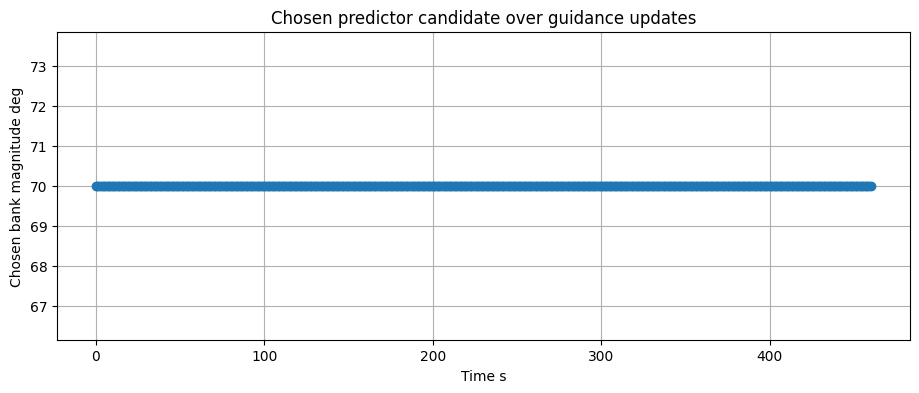

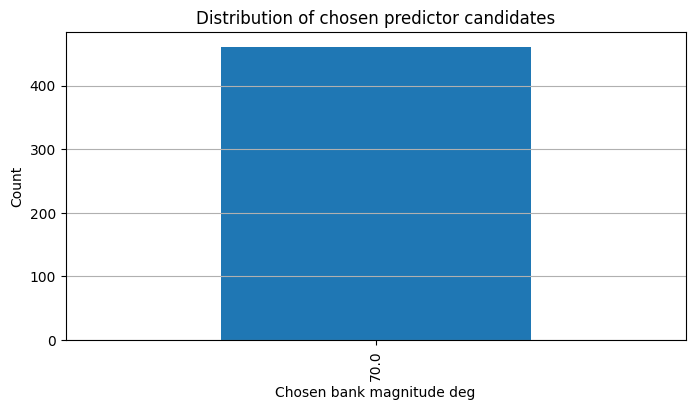

In [15]:
# Guidance candidate choice diagnostics
# Put this cell right after the DataFrame build cell

guidance_choice_df = df[df["guidance_updated"]].copy()

if len(guidance_choice_df) == 0:
    print("No guidance update rows were logged")
else:
    print("Number of guidance updates", len(guidance_choice_df))

    display(
        guidance_choice_df[
            [
                "t_s",
                "guidance_selected_candidate_index",
                "guidance_chosen_sigma_mag_deg",
                "guidance_chosen_sigma_cmd_deg",
                "guidance_selected_total_cost",
                "guidance_selected_candidate_heat_feasible",
            ]
        ].head(20)
    )

    chosen_counts = (
        guidance_choice_df["guidance_chosen_sigma_mag_deg"]
        .value_counts(dropna=False)
        .sort_index()
    )

    print("Chosen candidate counts")
    display(chosen_counts.rename("count").to_frame())

    plt.figure(figsize=(11, 4))
    plt.plot(
        guidance_choice_df["t_s"],
        guidance_choice_df["guidance_chosen_sigma_mag_deg"],
        marker="o",
        linewidth=1.5,
    )
    plt.xlabel("Time s")
    plt.ylabel("Chosen bank magnitude deg")
    plt.title("Chosen predictor candidate over guidance updates")
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 4))
    chosen_counts.plot(kind="bar")
    plt.xlabel("Chosen bank magnitude deg")
    plt.ylabel("Count")
    plt.title("Distribution of chosen predictor candidates")
    plt.grid(True, axis="y")
    plt.show()

# quick summary ---------------------

In [16]:
# Quick summary table of the conditional uncertainty outputs

cols = [
    "t_s",
    "sigma_cmd_rad",
    "sigma_target_rad",
    "sigma_actual_rad",
    "roll_rate_rad_s",
    "tau_roll_cmd_Nm",
    "requested_duty",
    "fired_this_step",
    "alt_m",
    "interval_alt_lo",
    "interval_alt_hi",
    "V_mps",
    "V_mps_lo",
    "V_mps_hi",
    "interval_rho_lo",
    "interval_rho_hi",
    "interval_q_lo",
    "interval_q_hi",
    "T_K",
    "p_Pa",
    "safety_status",
]

df[cols].head(12)

,t_s,sigma_cmd_rad,sigma_target_rad,sigma_actual_rad,roll_rate_rad_s,tau_roll_cmd_Nm,requested_duty,fired_this_step,alt_m,interval_alt_lo,...,V_mps,V_mps_lo,V_mps_hi,interval_rho_lo,interval_rho_hi,interval_q_lo,interval_q_hi,T_K,p_Pa,safety_status
0,0.00,1.22173,0.043633,0.000000,0.000000,349.065850,0.061307,0,300000.000000,299990.000000,...,7500.000000,7480.208338,7520.219985,2.035156e-11,2.036120e-11,0.000569,0.000576,NaN,NaN,outside
1,0.25,1.22173,0.130900,0.000000,0.000000,1047.197551,0.183921,0,299820.289214,299804.911439,...,7500.214163,7480.416722,7520.440024,2.042887e-11,2.044237e-11,0.000572,0.000578,NaN,NaN,outside
2,0.50,1.22173,0.218166,0.003388,0.024198,1745.329252,0.306536,1,299640.541418,299619.782620,...,7500.428375,7480.625151,7520.660117,2.050562e-11,2.052393e-11,0.000574,0.000580,NaN,NaN,outside
3,0.75,1.22173,0.305433,0.012576,0.054090,2319.565526,0.407390,1,299460.756625,299434.613552,...,7500.642636,7480.833626,7520.880263,2.058272e-11,2.060587e-11,0.000576,0.000583,NaN,NaN,outside
4,1.00,1.22173,0.392699,0.029536,0.086829,2824.623057,0.496094,1,299280.934847,299249.404245,...,7500.856947,7481.042146,7521.100463,2.066015e-11,2.068819e-11,0.000578,0.000585,NaN,NaN,outside
5,1.25,1.22173,0.479966,0.055528,0.126685,3256.117678,0.571878,1,299101.076095,299064.154708,...,7501.071308,7481.250712,7521.320716,2.073793e-11,2.077087e-11,0.000580,0.000587,NaN,NaN,outside
6,1.50,1.22173,0.567232,0.092053,0.170812,3586.890328,0.629973,1,298921.180381,298878.864951,...,7501.285718,7481.459322,7521.541023,2.081603e-11,2.085396e-11,0.000583,0.000590,NaN,NaN,outside
7,1.75,1.22173,0.654498,0.139752,0.222055,3816.314697,0.670267,1,298741.247718,298693.534984,...,7501.500177,7481.667979,7521.761383,2.089447e-11,2.093741e-11,0.000585,0.000592,NaN,NaN,outside
8,2.00,1.22173,0.741765,0.199501,0.270452,3927.878985,0.689861,1,298561.278118,298508.164817,...,7501.714686,7481.876680,7521.981797,2.097327e-11,2.102127e-11,0.000587,0.000595,NaN,NaN,outside
9,2.25,1.22173,0.829031,0.271470,0.317425,3954.435980,0.694525,1,298381.271593,298322.754457,...,7501.929245,7482.085427,7522.202265,2.105239e-11,2.110552e-11,0.000589,0.000597,NaN,NaN,outside


# was the landing target reached

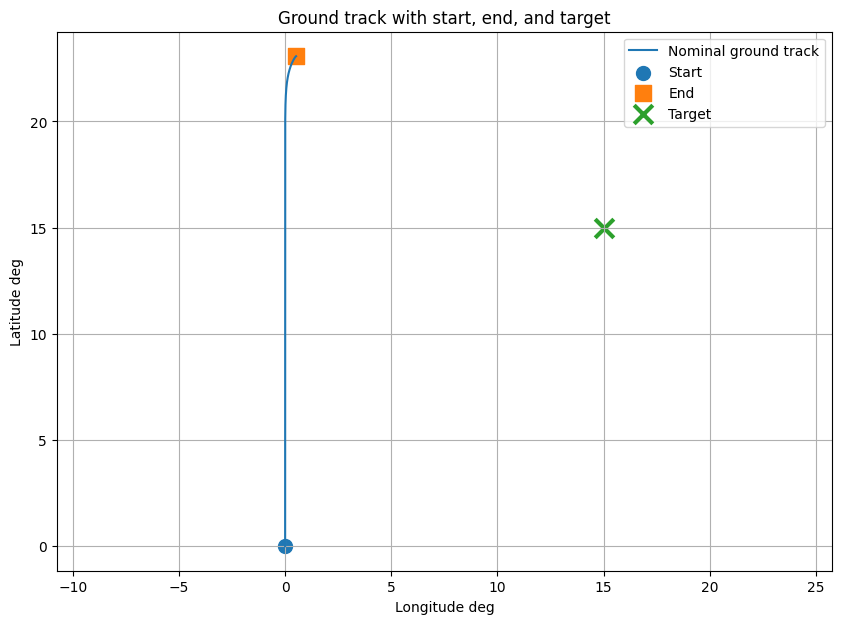

Start latitude deg 0.0
Start longitude deg 0.0
End latitude deg 23.073290486453082
End longitude deg 0.5146744134258913
Target latitude deg 14.999999999999998
Target longitude deg 14.999999999999998
North error m 898709.37247462
East error m -1557545.4594332203
Planar ground error m 1798228.6824469147
Great circle surface error m 1767661.1171056102


,start_lat_deg,start_lon_deg,end_lat_deg,end_lon_deg,target_lat_deg,target_lon_deg,north_error_m,east_error_m,planar_ground_error_m,great_circle_error_m
0,0.0,0.0,23.07329,0.514674,15.0,15.0,898709.372475,-1.557545e+06,1.798229e+06,1.767661e+06


In [17]:
# Ground track, target comparison, and landing error summary

if len(df) == 0:
    raise ValueError("The dataframe is empty. Run the main loop cell first.")

# Convert trajectory states to degrees for plotting
track_df = df.copy()
track_df["phi_deg"] = np.degrees(track_df["phi_rad"])
track_df["lam_deg"] = np.degrees(track_df["lam_rad"])

# Start and end points from the nominal path
start_phi_deg = float(track_df["phi_deg"].iloc[0])
start_lam_deg = float(track_df["lam_deg"].iloc[0])

end_phi_deg = float(track_df["phi_deg"].iloc[-1])
end_lam_deg = float(track_df["lam_deg"].iloc[-1])

# Target point in degrees
target_phi_deg = float(np.degrees(target_phi_rad))
target_lam_deg = float(np.degrees(target_lam_rad))

# Final nominal state error relative to target
R_earth_m = float(constants.RADIUS_EARTH)

dphi_rad = float(track_df["phi_rad"].iloc[-1] - target_phi_rad)
dlam_rad = float(track_df["lam_rad"].iloc[-1] - target_lam_rad)

north_error_m = R_earth_m * dphi_rad
east_error_m = R_earth_m * dlam_rad * math.cos(target_phi_rad)
ground_error_m = math.sqrt(north_error_m**2 + east_error_m**2)

# Great circle style angular distance and surface distance
sin_dphi_2 = math.sin(dphi_rad / 2.0)
sin_dlam_2 = math.sin(dlam_rad / 2.0)
a = (
    sin_dphi_2**2
    + math.cos(float(track_df["phi_rad"].iloc[-1])) * math.cos(target_phi_rad) * sin_dlam_2**2
)
a = min(1.0, max(0.0, a))
central_angle_rad = 2.0 * math.asin(math.sqrt(a))
great_circle_error_m = R_earth_m * central_angle_rad

# Plot the nominal ground track and mark start, end, and target
plt.figure(figsize=(10, 7))
plt.plot(track_df["lam_deg"], track_df["phi_deg"], label="Nominal ground track")
plt.scatter(start_lam_deg, start_phi_deg, s=100, marker="o", label="Start")
plt.scatter(end_lam_deg, end_phi_deg, s=120, marker="s", label="End")
plt.scatter(target_lam_deg, target_phi_deg, s=180, marker="x", linewidths=3, label="Target")

plt.xlabel("Longitude deg")
plt.ylabel("Latitude deg")
plt.title("Ground track with start, end, and target")
plt.legend()
plt.grid(True)
plt.axis("equal")
plt.show()

# Optional zoomed view around the target and end point
lon_vals = [start_lam_deg, end_lam_deg, target_lam_deg]
lat_vals = [start_phi_deg, end_phi_deg, target_phi_deg]

lon_pad = max(0.5, 0.15 * (max(lon_vals) - min(lon_vals) + 1.0))
lat_pad = max(0.5, 0.15 * (max(lat_vals) - min(lat_vals) + 1.0))

# Print a compact landing style summary
print("Start latitude deg", start_phi_deg)
print("Start longitude deg", start_lam_deg)
print("End latitude deg", end_phi_deg)
print("End longitude deg", end_lam_deg)
print("Target latitude deg", target_phi_deg)
print("Target longitude deg", target_lam_deg)
print("North error m", north_error_m)
print("East error m", east_error_m)
print("Planar ground error m", ground_error_m)
print("Great circle surface error m", great_circle_error_m)

# Tabular summary
landing_summary_df = pd.DataFrame(
    [
        {
            "start_lat_deg": start_phi_deg,
            "start_lon_deg": start_lam_deg,
            "end_lat_deg": end_phi_deg,
            "end_lon_deg": end_lam_deg,
            "target_lat_deg": target_phi_deg,
            "target_lon_deg": target_lam_deg,
            "north_error_m": north_error_m,
            "east_error_m": east_error_m,
            "planar_ground_error_m": ground_error_m,
            "great_circle_error_m": great_circle_error_m,
        }
    ]
)

landing_summary_df

# approx total nominal path travelled

In [18]:
# Approximate total nominal path length traveled

if len(df) < 2:
    raise ValueError("Need at least two trajectory rows in df")

R_earth_m = float(constants.RADIUS_EARTH)

segment_lengths_m = []

for i in range(1, len(df)):
    r1 = float(df.iloc[i - 1]["r_m"])
    r2 = float(df.iloc[i]["r_m"])

    phi1 = float(df.iloc[i - 1]["phi_rad"])
    phi2 = float(df.iloc[i]["phi_rad"])

    lam1 = float(df.iloc[i - 1]["lam_rad"])
    lam2 = float(df.iloc[i]["lam_rad"])

    x1 = r1 * math.cos(phi1) * math.cos(lam1)
    y1 = r1 * math.cos(phi1) * math.sin(lam1)
    z1 = r1 * math.sin(phi1)

    x2 = r2 * math.cos(phi2) * math.cos(lam2)
    y2 = r2 * math.cos(phi2) * math.sin(lam2)
    z2 = r2 * math.sin(phi2)

    ds = math.sqrt((x2 - x1)**2 + (y2 - y1)**2 + (z2 - z1)**2)
    segment_lengths_m.append(ds)

total_distance_m = float(np.sum(segment_lengths_m))
total_distance_km = total_distance_m / 1000.0

print("Approximate total nominal path length m", total_distance_m)
print("Approximate total nominal path length km", total_distance_km)

Approximate total nominal path length m 2663695.7808961873
Approximate total nominal path length km 2663.6957808961874


# 3D trajectory

ValueError: Axis limits cannot be NaN or Inf

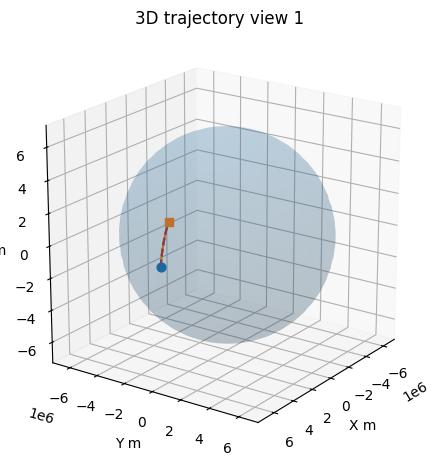

In [19]:
# 3D trajectory from four viewing angles with conservative interval corner curves

from mpl_toolkits.mplot3d import Axes3D

def spherical_to_cartesian(r, phi, lam):
    x = r * np.cos(phi) * np.cos(lam)
    y = r * np.cos(phi) * np.sin(lam)
    z = r * np.sin(phi)
    return x, y, z

# Nominal trajectory
r_nom = df["r_m"].to_numpy(dtype=float)
phi_nom = df["phi_rad"].to_numpy(dtype=float)
lam_nom = df["lam_rad"].to_numpy(dtype=float)

x_nom, y_nom, z_nom = spherical_to_cartesian(r_nom, phi_nom, lam_nom)

# Conservative interval corner trajectories
r_lo = df["r_m_lo"].to_numpy(dtype=float)
r_hi = df["r_m_hi"].to_numpy(dtype=float)

phi_lo = df["phi_rad_lo"].to_numpy(dtype=float)
phi_hi = df["phi_rad_hi"].to_numpy(dtype=float)

lam_lo = df["lam_rad_lo"].to_numpy(dtype=float)
lam_hi = df["lam_rad_hi"].to_numpy(dtype=float)

x_lo, y_lo, z_lo = spherical_to_cartesian(r_lo, phi_lo, lam_lo)
x_hi, y_hi, z_hi = spherical_to_cartesian(r_hi, phi_hi, lam_hi)

# Earth sphere for reference
u = np.linspace(0.0, 2.0 * np.pi, 60)
v = np.linspace(-0.5 * np.pi, 0.5 * np.pi, 30)
uu, vv = np.meshgrid(u, v)

x_e = R_earth_m * np.cos(vv) * np.cos(uu)
y_e = R_earth_m * np.cos(vv) * np.sin(uu)
z_e = R_earth_m * np.sin(vv)

fig = plt.figure(figsize=(14, 12))
views = [(20, 35), (20, 125), (50, 215), (80, 300)]

for idx, (elev, azim) in enumerate(views, start=1):
    ax = fig.add_subplot(2, 2, idx, projection="3d")

    ax.plot_surface(x_e, y_e, z_e, alpha=0.15, linewidth=0)

    ax.plot(x_nom, y_nom, z_nom, label="Nominal trajectory")
    ax.plot(x_lo, y_lo, z_lo, linestyle="--", label="Interval low corner")
    ax.plot(x_hi, y_hi, z_hi, linestyle="--", label="Interval high corner")

    ax.scatter(x_nom[0], y_nom[0], z_nom[0], marker="o", s=40, label="Start" if idx == 1 else None)
    ax.scatter(x_nom[-1], y_nom[-1], z_nom[-1], marker="s", s=40, label="End" if idx == 1 else None)

    ax.set_xlabel("X m")
    ax.set_ylabel("Y m")
    ax.set_zlabel("Z m")
    ax.set_title(f"3D trajectory view {idx}")
    ax.view_init(elev=elev, azim=azim)
    ax.set_box_aspect((1, 1, 1))

    max_extent = np.max(np.abs(np.concatenate([x_nom, y_nom, z_nom, x_hi, y_hi, z_hi])))
    ax.set_xlim(-max_extent, max_extent)
    ax.set_ylim(-max_extent, max_extent)
    ax.set_zlim(-max_extent, max_extent)

    if idx == 1:
        ax.legend()

plt.tight_layout()
plt.show()

## more 3D views

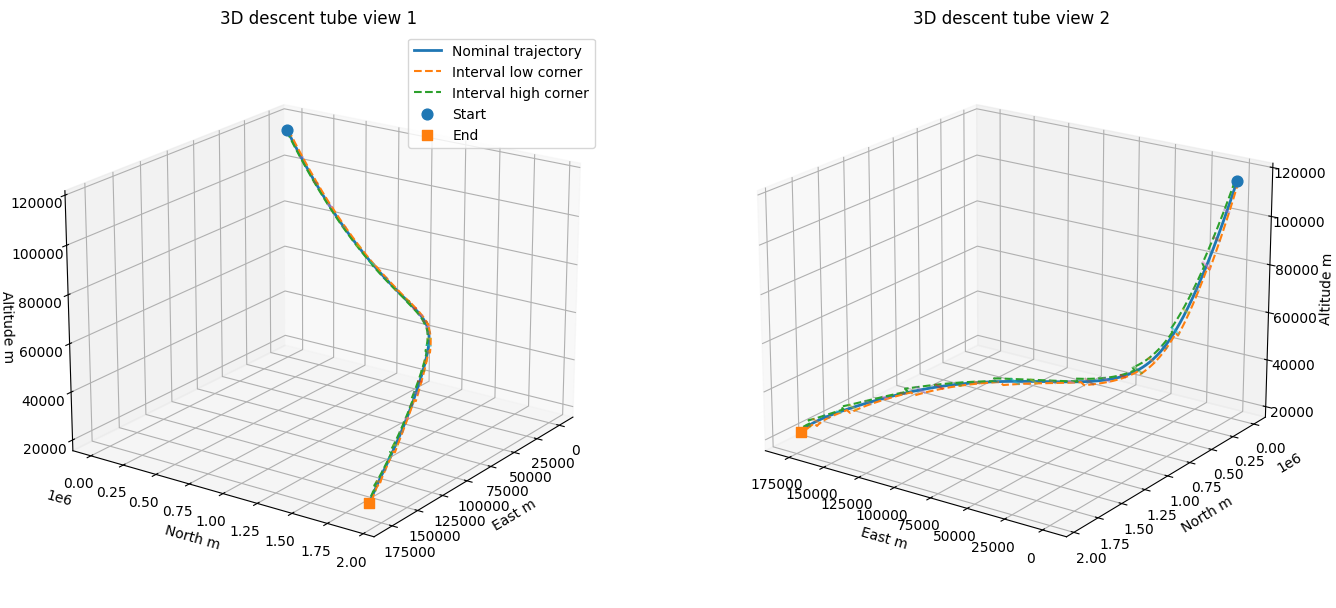

In [ ]:
# 3D descent tube view centered on the trajectory instead of the whole Earth

# A 3D path needs at least two trajectory samples so there is a start and an end to draw.
if len(df) < 2:
    raise ValueError("Need at least two rows in df to plot the 3D trajectory")

# Read the Earth radius once so the latitude and longitude offsets can be converted into meters.
R_earth_m = float(constants.RADIUS_EARTH)

# Use the first trajectory point as the local reference origin for the tangent plane view.
phi0 = float(df["phi_rad"].iloc[0])
lam0 = float(df["lam_rad"].iloc[0])

# This helper maps latitude, longitude, and altitude into a local east north up frame.
# The approximation is local, so it is most useful when the path is viewed relative to the start point.
def local_track_from_lat_lon_alt(phi_rad, lam_rad, alt_m, phi_ref_rad, lam_ref_rad, R_m):
    # East distance comes from longitude change scaled by the cosine of the reference latitude.
    east_m = R_m * (lam_rad - lam_ref_rad) * math.cos(phi_ref_rad)

    # North distance comes directly from latitude change.
    north_m = R_m * (phi_rad - phi_ref_rad)

    # Up is just the altitude above the surface.
    up_m = alt_m

    # Return the local coordinates in meters.
    return east_m, north_m, up_m

# Store the nominal trajectory in local east north up coordinates.
east_nom = []
north_nom = []
up_nom = []

# Store the lower interval corner path so the uncertainty envelope can be drawn.
east_lo = []
north_lo = []
up_lo = []

# Store the upper interval corner path for the other side of the envelope.
east_hi = []
north_hi = []
up_hi = []

# Walk through every row so the nominal path and both interval corners are converted into the same local frame.
for _, row in df.iterrows():
    # Convert the nominal latitude, longitude, and altitude at this time step.
    e, n, u = local_track_from_lat_lon_alt(
        float(row["phi_rad"]),
        float(row["lam_rad"]),
        float(row["alt_m"]),
        phi0,
        lam0,
        R_earth_m,
    )

    # Save the nominal local coordinates.
    east_nom.append(e)
    north_nom.append(n)
    up_nom.append(u)

    # Convert the lower bound trajectory values into the same local frame.
    e_lo, n_lo, u_lo = local_track_from_lat_lon_alt(
        float(row["phi_rad_lo"]),
        float(row["lam_rad_lo"]),
        float(row["interval_alt_lo"]),
        phi0,
        lam0,
        R_earth_m,
    )

    # Save the lower interval corner coordinates.
    east_lo.append(e_lo)
    north_lo.append(n_lo)
    up_lo.append(u_lo)

    # Convert the upper bound trajectory values into the same local frame.
    e_hi, n_hi, u_hi = local_track_from_lat_lon_alt(
        float(row["phi_rad_hi"]),
        float(row["lam_rad_hi"]),
        float(row["interval_alt_hi"]),
        phi0,
        lam0,
        R_earth_m,
    )

    # Save the upper interval corner coordinates.
    east_hi.append(e_hi)
    north_hi.append(n_hi)
    up_hi.append(u_hi)

# Convert the nominal coordinate lists into numpy arrays for plotting.
east_nom = np.array(east_nom)
north_nom = np.array(north_nom)
up_nom = np.array(up_nom)

# Convert the lower interval corner lists into numpy arrays.
east_lo = np.array(east_lo)
north_lo = np.array(north_lo)
up_lo = np.array(up_lo)

# Convert the upper interval corner lists into numpy arrays.
east_hi = np.array(east_hi)
north_hi = np.array(north_hi)
up_hi = np.array(up_hi)

# Import the 3D plotting toolkit used by matplotlib.
from mpl_toolkits.mplot3d import Axes3D

# Create a larger figure so the 3D views are easier to read.
fig = plt.figure(figsize=(14, 12))

# Define several camera angles, even though only the first two will be shown here.
views = [(20, 35), (20, 125), (35, 215), (70, 300)]

# Only show the first two viewing angles so the figure stays compact.
for idx, (elev, azim) in enumerate(views[:2], start=1):
    # Create a 3D subplot for this view.
    ax = fig.add_subplot(2, 2, idx, projection="3d")

    # Draw the nominal trajectory as the center line of the descent path.
    ax.plot(east_nom, north_nom, up_nom, linewidth=2, label="Nominal trajectory")

    # Draw the lower interval corner as one side of the uncertainty envelope.
    ax.plot(east_lo, north_lo, up_lo, linestyle="--", label="Interval low corner")

    # Draw the upper interval corner as the other side of the uncertainty envelope.
    ax.plot(east_hi, north_hi, up_hi, linestyle="--", label="Interval high corner")

    # Choose a stride so only some cross connections are drawn.
    # This keeps the envelope readable instead of cluttered.
    stride = max(1, len(df) // 30)

    # Connect matching low and high corner points so the interval looks more like a tube.
    for i in range(0, len(df), stride):
        ax.plot(
            [east_lo[i], east_hi[i]],
            [north_lo[i], north_hi[i]],
            [up_lo[i], up_hi[i]],
            alpha=0.5,
        )

    # Mark the first nominal point so the start of the descent is obvious.
    ax.scatter(east_nom[0], north_nom[0], up_nom[0], s=60, marker="o", label="Start" if idx == 1 else None)

    # Mark the last nominal point so the end of the descent is obvious.
    ax.scatter(east_nom[-1], north_nom[-1], up_nom[-1], s=60, marker="s", label="End" if idx == 1 else None)

    # Label the local coordinate axes in meters.
    ax.set_xlabel("East m")
    ax.set_ylabel("North m")
    ax.set_zlabel("Altitude m")

    # Give each panel a simple title based on the view number.
    ax.set_title(f"3D descent tube view {idx}")

    # Set the camera angle for this subplot.
    ax.view_init(elev=elev, azim=azim)

    # Show the legend only once so the figure does not repeat it in every panel.
    if idx == 1:
        ax.legend()

# Tighten layout spacing so the subplots fit cleanly in the figure.
plt.tight_layout()

# Render the completed 3D figure.
plt.show()

## did guidance even activate

In [ ]:
# Diagnose whether guidance is permanently disabled by the velocity gate

print("Minimum logged speed m/s:", df["V_mps"].min())
print("Maximum logged speed m/s:", df["V_mps"].max())
print("Any rows below 6000 m/s:", bool((df["V_mps"] <= 6000.0).any()))
print("Unique fired_this_step values:", sorted(df["fired_this_step"].unique()))
print("Max abs tau_roll_cmd_Nm:", float(np.abs(df["tau_roll_cmd_Nm"]).max()))
print("Max abs sigma_cmd_rad:", float(np.abs(df["sigma_cmd_rad"]).max()))
print("Max abs sigma_target_rad:", float(np.abs(df["sigma_target_rad"]).max()))

Minimum logged speed m/s: 501.97752032540643
Maximum logged speed m/s: 10518.899124848258
Any rows below 6000 m/s: True
Unique fired_this_step values: [np.int64(0), np.int64(1)]
Max abs tau_roll_cmd_Nm: 6000.0
Max abs sigma_cmd_rad: 1.2217304763960306
Max abs sigma_target_rad: 1.2217304763960306


In [ ]:
# Check whether the guidance command is identically zero

df[
    [
        "t_s",
        "V_mps",
        "sigma_cmd_rad",
        "sigma_target_rad",
        "sigma_actual_rad",
        "tau_roll_cmd_Nm",
        "requested_duty",
        "fired_this_step",
    ]
].head(20)

,t_s,V_mps,sigma_cmd_rad,sigma_target_rad,sigma_actual_rad,tau_roll_cmd_Nm,requested_duty,fired_this_step
0,0.00,10500.000000,1.22173,0.043633,0.000000,349.065850,0.061307,0
1,0.25,10500.224861,1.22173,0.130900,0.000000,1047.197551,0.183921,0
2,0.50,10500.449249,1.22173,0.218166,0.003388,1745.329252,0.306536,1
3,0.75,10500.673159,1.22173,0.305433,0.012576,2319.565526,0.407390,1
4,1.00,10500.896589,1.22173,0.392699,0.029536,2824.623057,0.496094,1
5,1.25,10501.119533,1.22173,0.479966,0.055528,3256.117678,0.571878,1
6,1.50,10501.341988,1.22173,0.567232,0.092053,3586.890328,0.629973,1
7,1.75,10501.563951,1.22173,0.654498,0.139752,3816.314697,0.670267,1
8,2.00,10501.785415,1.22173,0.741765,0.199501,3927.878985,0.689861,1
9,2.25,10502.006378,1.22173,0.829031,0.271470,3954.435980,0.694525,1


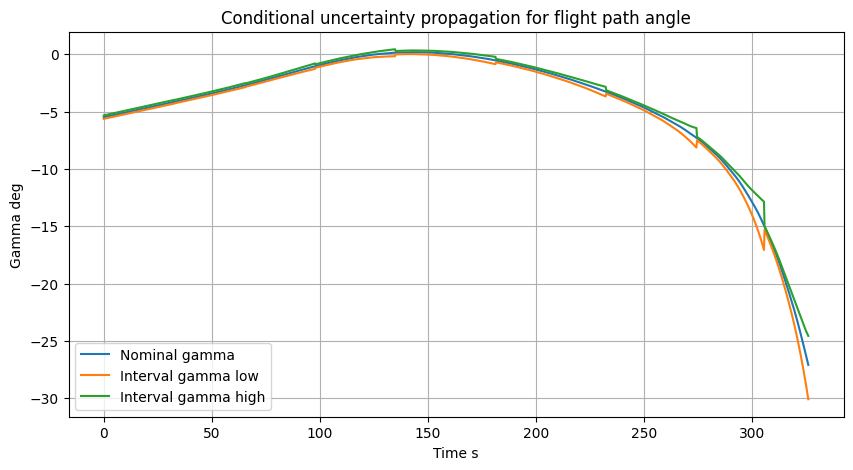

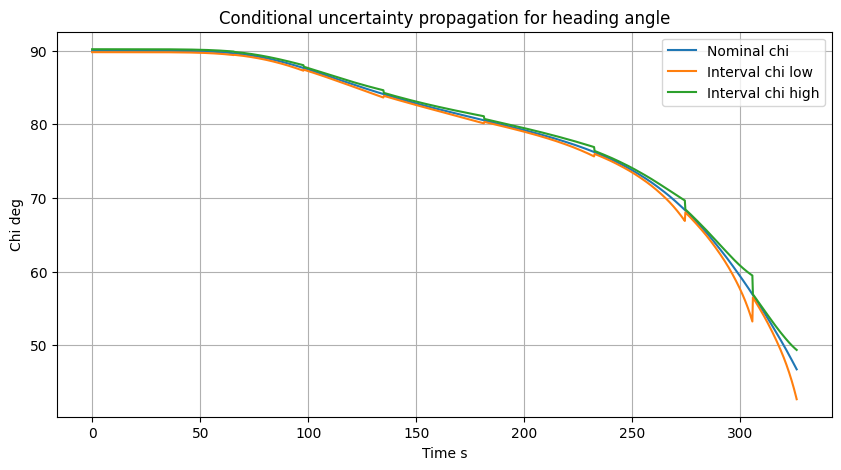

In [ ]:
# Plot flight path angle and heading interval envelopes

plt.figure(figsize=(10, 5))
plt.plot(df["t_s"], np.degrees(df["gamma_rad"]), label="Nominal gamma")
plt.plot(df["t_s"], np.degrees(df["gamma_rad_lo"]), label="Interval gamma low")
plt.plot(df["t_s"], np.degrees(df["gamma_rad_hi"]), label="Interval gamma high")
plt.xlabel("Time s")
plt.ylabel("Gamma deg")
plt.title("Conditional uncertainty propagation for flight path angle")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(df["t_s"], np.degrees(df["chi_rad"]), label="Nominal chi")
plt.plot(df["t_s"], np.degrees(df["chi_rad_lo"]), label="Interval chi low")
plt.plot(df["t_s"], np.degrees(df["chi_rad_hi"]), label="Interval chi high")
plt.xlabel("Time s")
plt.ylabel("Chi deg")
plt.title("Conditional uncertainty propagation for heading angle")
plt.legend()
plt.grid(True)
plt.show()

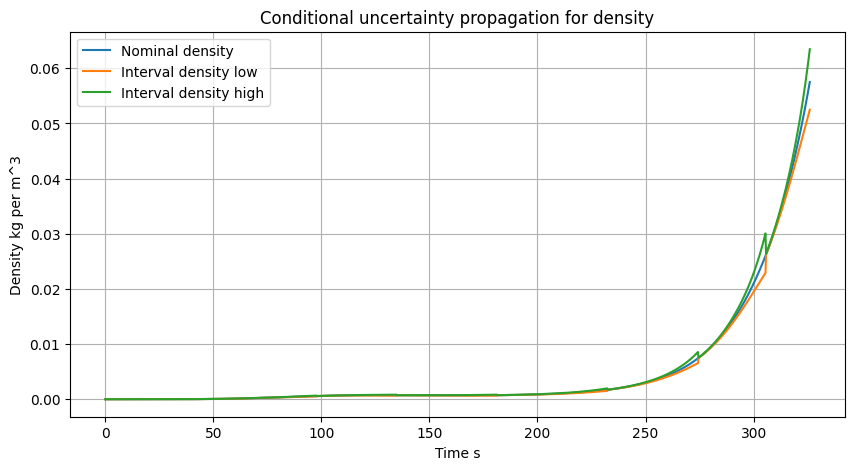

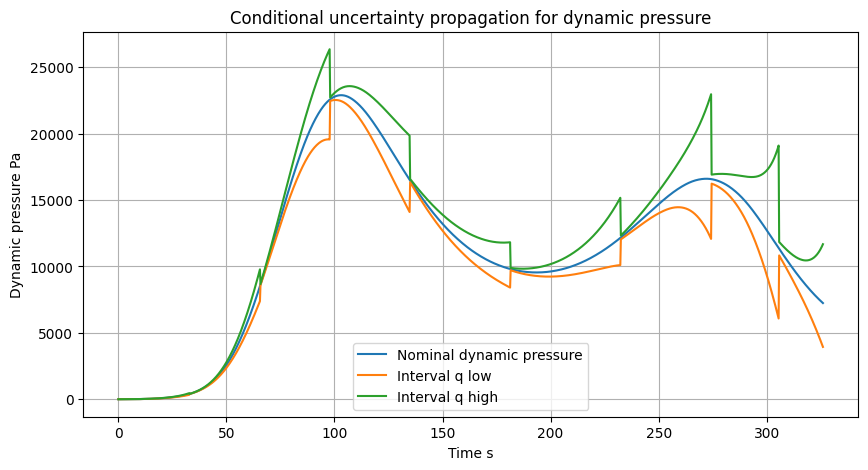

In [ ]:
# Plot density and dynamic pressure interval envelopes

plt.figure(figsize=(10, 5))
plt.plot(df["t_s"], df["rho_kgm3"], label="Nominal density")
plt.plot(df["t_s"], df["interval_rho_lo"], label="Interval density low")
plt.plot(df["t_s"], df["interval_rho_hi"], label="Interval density high")
plt.xlabel("Time s")
plt.ylabel("Density kg per m^3")
plt.title("Conditional uncertainty propagation for density")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(df["t_s"], df["q_pa"], label="Nominal dynamic pressure")
plt.plot(df["t_s"], df["interval_q_lo"], label="Interval q low")
plt.plot(df["t_s"], df["interval_q_hi"], label="Interval q high")
plt.xlabel("Time s")
plt.ylabel("Dynamic pressure Pa")
plt.title("Conditional uncertainty propagation for dynamic pressure")
plt.legend()
plt.grid(True)
plt.show()

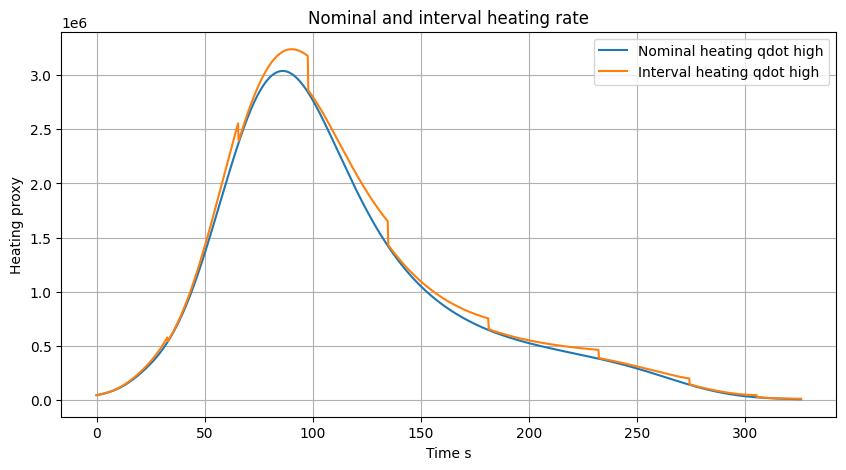

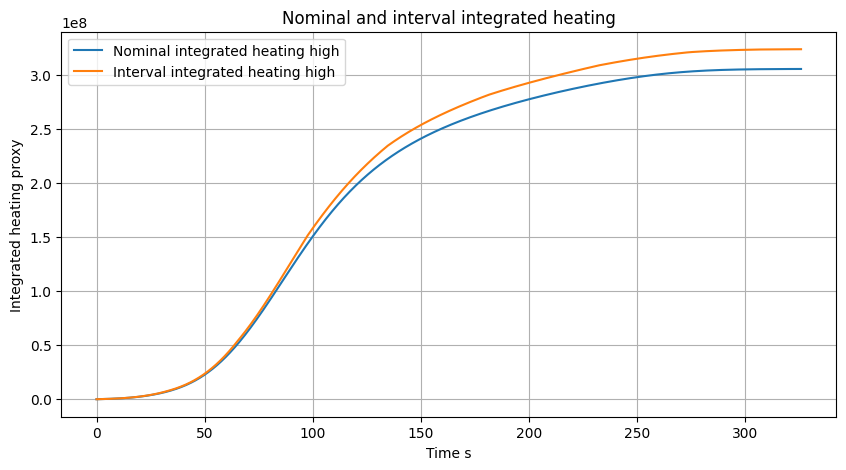

In [ ]:
# Plot interval and nominal heating with the interval failure marker

plt.figure(figsize=(10, 5))
plt.plot(df["t_s"], df["nominal_heat_qdot_max_hi"], label="Nominal heating qdot high")
plt.plot(df["t_s"], df["heating_qdot_max_hi"], label="Interval heating qdot high")

if len(df) > 0 and df["interval_failed"].max() > 0:
    t_fail = float(df[df["interval_failed"] == 1]["interval_failure_time_s"].iloc[0])
    plt.axvline(t_fail, linestyle="--", label="Interval failure time")

plt.xlabel("Time s")
plt.ylabel("Heating proxy")
plt.title("Nominal and interval heating rate")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(df["t_s"], df["nominal_heat_Q_max_hi"], label="Nominal integrated heating high")
plt.plot(df["t_s"], df["heating_Q_max_hi"], label="Interval integrated heating high")

if len(df) > 0 and df["interval_failed"].max() > 0:
    t_fail = float(df[df["interval_failed"] == 1]["interval_failure_time_s"].iloc[0])
    plt.axvline(t_fail, linestyle="--", label="Interval failure time")

plt.xlabel("Time s")
plt.ylabel("Integrated heating proxy")
plt.title("Nominal and interval integrated heating")
plt.legend()
plt.grid(True)
plt.show()


## heatshield heat maps

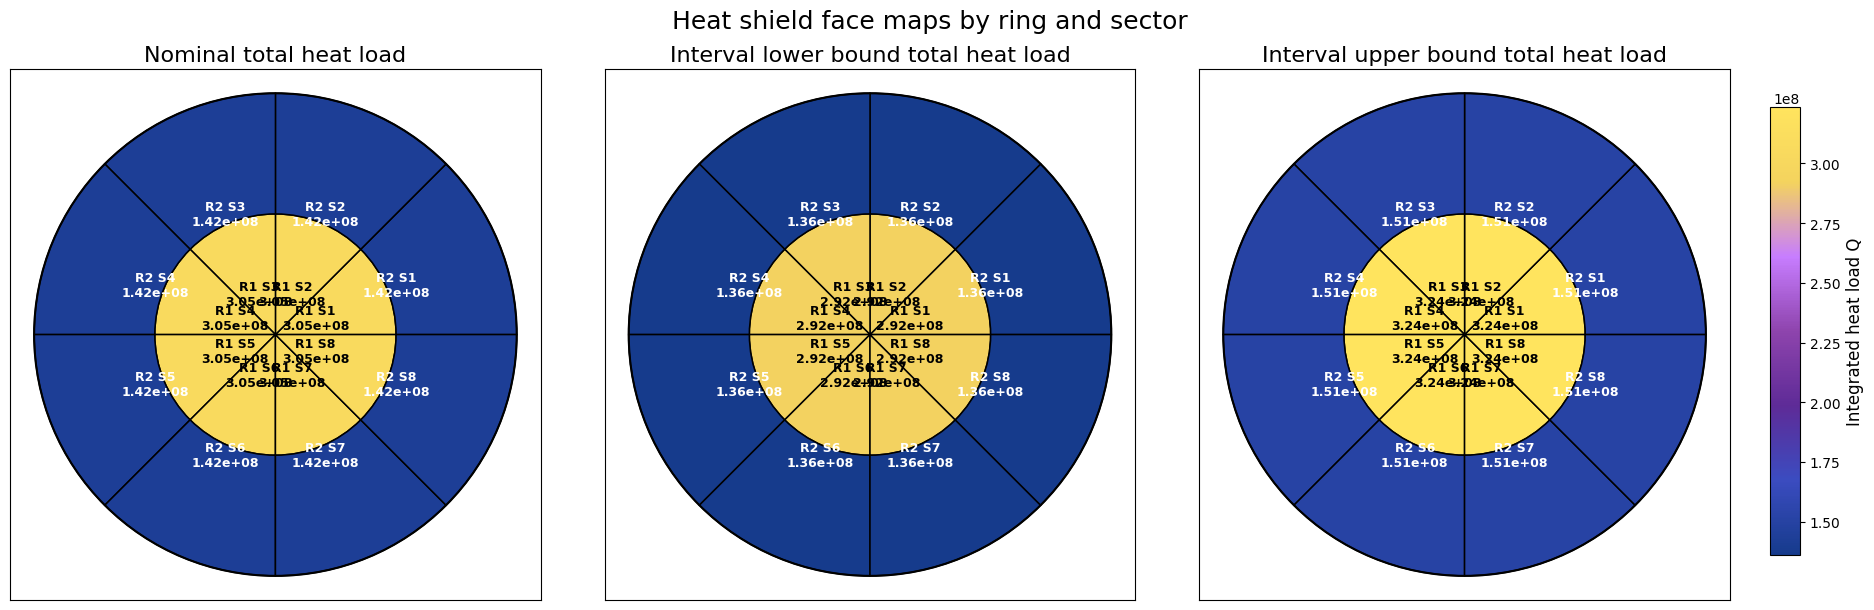

Nominal replay hot direction source: fallback_constant_zero


,ring_index,sector_index,ring_label,sector_label,r_inner_m,r_outer_m,r_center_m,theta_lo_deg,theta_hi_deg,theta_center_deg,cell_area_m2,Q_nominal,Q_interval_lo,Q_interval_hi
0,0,0,R1,S1,0.00,1.25,0.625,0.0,45.0,22.5,0.613592,3.053393e+08,2.915369e+08,3.235962e+08
1,0,1,R1,S2,0.00,1.25,0.625,45.0,90.0,67.5,0.613592,3.053393e+08,2.915369e+08,3.235962e+08
2,0,2,R1,S3,0.00,1.25,0.625,90.0,135.0,112.5,0.613592,3.053393e+08,2.915369e+08,3.235962e+08
3,0,3,R1,S4,0.00,1.25,0.625,135.0,180.0,157.5,0.613592,3.053393e+08,2.915369e+08,3.235962e+08
4,0,4,R1,S5,0.00,1.25,0.625,180.0,225.0,202.5,0.613592,3.053393e+08,2.915369e+08,3.235962e+08
5,0,5,R1,S6,0.00,1.25,0.625,225.0,270.0,247.5,0.613592,3.053393e+08,2.915369e+08,3.235962e+08
6,0,6,R1,S7,0.00,1.25,0.625,270.0,315.0,292.5,0.613592,3.053393e+08,2.915369e+08,3.235962e+08
7,0,7,R1,S8,0.00,1.25,0.625,315.0,360.0,337.5,0.613592,3.053393e+08,2.915369e+08,3.235962e+08
8,1,0,R2,S1,1.25,2.50,1.875,0.0,45.0,22.5,1.840777,1.424917e+08,1.360506e+08,1.510116e+08
9,1,1,R2,S2,1.25,2.50,1.875,45.0,90.0,67.5,1.840777,1.424917e+08,1.360506e+08,1.510116e+08


In [ ]:
# Heat shield face maps for total integrated heat load
#
# This cell replaces the old ring only plotting logic with a ring and sector plot.
# It assumes the HeatShield class has already been upgraded so that the shield is
# split into both radial rings and angular sectors.
#
# What this cell shows
# The first panel shows the nominal final integrated heat load by shield cell.
# The second panel shows the interval lower bound final integrated heat load by shield cell.
# The third panel shows the interval upper bound final integrated heat load by shield cell.
#
# Why this cell is different from the earlier version
# The earlier version drew each ring as a full circular annulus.
# That was correct only for the old radial only shield model.
# This new version draws each shield cell as an annular sector.
# That allows the face map to show both radial and angular heating structure.
#
# Important modeling note
# This plotting cell can only display directional heating that already exists in the
# underlying heat shield data. If the simulation updated the heat shield with a fixed
# hot direction for every step, then the sectors will still look symmetric over time.
# For a truly moving hot region, the main heating update path must pass a changing
# hot_theta_rad during the simulation.
#
# Design choices in this cell
# One shared color scale is used across all three panels.
# That makes the colors directly comparable between nominal lower bound and upper bound.
#
# The colorbar is placed in its own dedicated axis on the far right.
# That prevents any overlap with the third panel.
#
# Labels are only drawn when the number of shield cells is modest.
# For a coarse grid such as 2 rings by 4 sectors, labels remain readable.
# For finer grids, the plot stays clean and the numeric values are still available
# in the summary DataFrame shown below the figure.

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Wedge
from matplotlib.colors import Normalize, LinearSegmentedColormap
from matplotlib.cm import ScalarMappable
from interval_math import promote

# Validate that the required simulation objects exist

# The DataFrame is needed so the nominal shield can be reconstructed by replaying
# the nominal trajectory heating one time step at a time.
if "df" not in globals() or len(df) == 0:
    raise ValueError("df is missing or empty. Run the main simulation loop first.")

# The interval heat shield must already exist because it carries the interval based
# accumulated heat loads that are visualized in the second and third panels.
if "interval_heat_shield" not in globals() or interval_heat_shield is None:
    raise ValueError("interval_heat_shield is missing. Run the main simulation loop first with heating enabled.")

# This revised plotting cell expects the upgraded HeatShield class that stores
# ring sector geometry. If these attributes are missing, the notebook is still
# using the old ring only HeatShield implementation.
required_sector_attrs = [
    "num_sectors",
    "theta_edges",
    "theta_centers",
    "cell_ring_index",
    "cell_sector_index",
    "cell_r_inner",
    "cell_r_outer",
    "cell_r_center",
    "cell_theta_lo",
    "cell_theta_hi",
    "cell_theta_center",
    "cell_area",
]
missing_sector_attrs = [name for name in required_sector_attrs if not hasattr(interval_heat_shield, name)]
if missing_sector_attrs:
    raise ValueError(
        "interval_heat_shield is missing sector geometry attributes. "
        "Make sure the upgraded HeatShield class has been loaded before running this cell. "
        f"Missing attributes: {missing_sector_attrs}"
    )

# Small helpers for direction replay and label formatting

def get_hot_theta_from_row(row):
    """
    Return the heating direction angle to use for nominal replay.

    Preferred behavior
    If the main loop logged a dedicated heating direction column, use it.

    Fallback behavior
    If no such column exists, fall back to 0.0 so the nominal replay still runs.
    That fallback keeps the code stable, but it does not create a moving hot region.
    """
    candidate_columns = [
        "hot_theta_rad",
        "heating_hot_theta_rad",
        "shield_hot_theta_rad",
    ]

    for col in candidate_columns:
        if col in row.index and pd.notna(row[col]):
            return float(row[col]), col

    return 0.0, "fallback_constant_zero"

def choose_text_color(value, norm):
    """
    Choose a text color that stays readable against the cell color.
    """
    return "white" if norm(value) < 0.58 else "black"

def should_draw_labels(n_cells_total):
    """
    Draw labels only when the shield resolution is still visually readable.
    """
    return n_cells_total <= 16

# Build a fresh nominal heat shield and replay the nominal heating history

# Pull the discretization from constants when available.
# If the constants file is not yet updated, fall back to the geometry already
# present on the interval shield so that nominal and interval plots still align.
num_rings_to_use = int(getattr(constants, "HEAT_SHIELD_NUM_RINGS", interval_heat_shield.num_rings))
num_sectors_to_use = int(getattr(constants, "HEAT_SHIELD_NUM_SECTORS", interval_heat_shield.num_sectors))
radial_exp_to_use = float(getattr(constants, "HEAT_SHIELD_RADIAL_EXP", 1.0))
azimuthal_gain_to_use = float(getattr(constants, "HEAT_SHIELD_AZIMUTHAL_GAIN", 0.0))

# Rebuild a nominal shield using the same geometry settings that the upgraded class expects.
# This nominal shield is separate from the interval shield because the nominal replay uses
# point values rather than interval bounds.
nominal_heat_shield = constants.HeatShield(
    radius_m=float(constants.HEAT_SHIELD_RADIUS_M),
    nose_radius_m=float(constants.HEAT_SHIELD_NOSE_RADIUS_M),
    num_rings=num_rings_to_use,
    num_sectors=num_sectors_to_use,
    radial_exp=radial_exp_to_use,
    azimuthal_gain=azimuthal_gain_to_use,
)

# Confirm that the nominal replay shield and the interval shield describe the same
# number of cells. The plotting logic assumes a one to one correspondence.
if len(nominal_heat_shield.Q) != len(interval_heat_shield.Q):
    raise ValueError(
        "Nominal shield cell count does not match interval shield cell count. "
        "Make sure the notebook is using the same ring and sector settings for both."
    )

# Replay the nominal heat history step by step.
# Each time step uses the logged nominal density and speed.
# If a heating direction column exists, it is also replayed here.
direction_source_name = None

for _, row in df.iterrows():
    rho_nom = promote(float(row["rho_kgm3"]))
    V_nom = promote(float(row["V_mps"]))
    hot_theta_rad, direction_source_name = get_hot_theta_from_row(row)

    nominal_heat_shield.update(
        rho=rho_nom,
        V=V_nom,
        dt=float(dt_s),
        hot_theta_rad=float(hot_theta_rad),
    )

# Extract final cellwise integrated heat values for all three cases

# The nominal shield stores punctual intervals, so mid returns the scalar value cleanly.
# The interval shield stores lower and upper bounds for each cell.
nominal_Q = np.array([float(q.mid()) for q in nominal_heat_shield.Q], dtype=float)
lower_Q = np.array([float(q.lo) for q in interval_heat_shield.Q], dtype=float)
upper_Q = np.array([float(q.hi) for q in interval_heat_shield.Q], dtype=float)

# Extract shield cell geometry from the interval shield

# These arrays describe the exact annular sector geometry for every shield cell.
# They are used to draw the face maps.
cell_ring_index = np.array(interval_heat_shield.cell_ring_index, dtype=int)
cell_sector_index = np.array(interval_heat_shield.cell_sector_index, dtype=int)
cell_r_inner = np.array(interval_heat_shield.cell_r_inner, dtype=float)
cell_r_outer = np.array(interval_heat_shield.cell_r_outer, dtype=float)
cell_r_center = np.array(interval_heat_shield.cell_r_center, dtype=float)
cell_theta_lo = np.array(interval_heat_shield.cell_theta_lo, dtype=float)
cell_theta_hi = np.array(interval_heat_shield.cell_theta_hi, dtype=float)
cell_theta_center = np.array(interval_heat_shield.cell_theta_center, dtype=float)
cell_area = np.array(interval_heat_shield.cell_area, dtype=float)

shield_radius = float(interval_heat_shield.radius)
n_cells_total = len(cell_area)

# Build one shared color scale across all three panels

# A single normalization makes color comparisons fair across all three scenarios.
all_vals = np.concatenate([nominal_Q, lower_Q, upper_Q])
vmin = float(np.min(all_vals))
vmax = float(np.max(all_vals))

# Avoid a zero width normalization range in the degenerate case where all values match.
if np.isclose(vmin, vmax):
    vmax = vmin + 1.0

norm = Normalize(vmin=vmin, vmax=vmax)

# Colormap design
# Lower values move through blue and purple
# Higher values move toward bright yellow
cmap = LinearSegmentedColormap.from_list(
    "blue_purple_yellow",
    [
        "#163b8c",
        "#3b4cc0",
        "#5e2b97",
        "#8e44ad",
        "#c77dff",
        "#f4d35e",
        "#ffe45e",
    ],
    N=256,
)

# Helper function to draw one full shield face map using annular sectors

def draw_sector_heatmap(ax, values, title):
    """
    Draw one shield face map.

    Each shield cell is drawn as a wedge with:
    inner radius from the ring geometry
    outer radius from the ring geometry
    starting angle from the sector geometry
    ending angle from the sector geometry

    This is the key difference from the old ring only plot.
    Instead of drawing full circles, this draws individual ring sector cells.
    """
    ax.set_aspect("equal")
    ax.set_xlim(-shield_radius * 1.10, shield_radius * 1.10)
    ax.set_ylim(-shield_radius * 1.10, shield_radius * 1.10)

    # Draw every ring sector cell.
    for cell_idx, value in enumerate(values):
        r_inner = cell_r_inner[cell_idx]
        r_outer = cell_r_outer[cell_idx]
        theta_lo_deg = math.degrees(cell_theta_lo[cell_idx])
        theta_hi_deg = math.degrees(cell_theta_hi[cell_idx])

        patch = Wedge(
            center=(0.0, 0.0),
            r=r_outer,
            theta1=theta_lo_deg,
            theta2=theta_hi_deg,
            width=(r_outer - r_inner),
            facecolor=cmap(norm(value)),
            edgecolor="black",
            linewidth=1.1,
        )
        ax.add_patch(patch)

    # Add the outer shield boundary so the full face remains visually crisp
    outer_boundary = plt.Circle(
        (0.0, 0.0),
        shield_radius,
        fill=False,
        color="black",
        linewidth=1.5,
    )
    ax.add_artist(outer_boundary)
    
    # Draw labels only for modest cell counts.
    # Fine grids become unreadable if every cell is labeled on the plot itself
    if should_draw_labels(n_cells_total):
        for cell_idx, value in enumerate(values):
            theta = cell_theta_center[cell_idx]
            r_label = 0.72 * cell_r_center[cell_idx]
            x_label = r_label * math.cos(theta)
            y_label = r_label * math.sin(theta)

            ring_id = cell_ring_index[cell_idx] + 1
            sector_id = cell_sector_index[cell_idx] + 1

            ax.text(
                x_label,
                y_label,
                f"R{ring_id} S{sector_id}\n{value:.2e}",
                ha="center",
                va="center",
                fontsize=9,
                color=choose_text_color(value, norm),
                fontweight="bold",
            )

    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title, fontsize=16)

# Create the figure and draw the three panels

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

# Leave space on the right for a dedicated colorbar axis
fig.subplots_adjust(left=0.04, right=0.90, wspace=0.12)

draw_sector_heatmap(axes[0], nominal_Q, "Nominal total heat load")
draw_sector_heatmap(axes[1], lower_Q, "Interval lower bound total heat load")
draw_sector_heatmap(axes[2], upper_Q, "Interval upper bound total heat load")

# Build a separate colorbar axis so it never overlaps the third panel
cbar_ax = fig.add_axes([0.92, 0.18, 0.015, 0.64])

sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label("Integrated heat load Q", fontsize=12)

fig.suptitle("Heat shield face maps by ring and sector", fontsize=18, y=0.96)

plt.show()

# Build a summary DataFrame with one row per shield cell

# This table is useful when the grid becomes fine enough that text labels are
# intentionally suppressed on the figure
heat_cells_df = pd.DataFrame({
    "ring_index": cell_ring_index,
    "sector_index": cell_sector_index,
    "ring_label": [f"R{i + 1}" for i in cell_ring_index],
    "sector_label": [f"S{i + 1}" for i in cell_sector_index],
    "r_inner_m": cell_r_inner,
    "r_outer_m": cell_r_outer,
    "r_center_m": cell_r_center,
    "theta_lo_deg": np.degrees(cell_theta_lo),
    "theta_hi_deg": np.degrees(cell_theta_hi),
    "theta_center_deg": np.degrees(cell_theta_center),
    "cell_area_m2": cell_area,
    "Q_nominal": nominal_Q,
    "Q_interval_lo": lower_Q,
    "Q_interval_hi": upper_Q,
})

# Print the direction source used for the nominal replay.
# This makes it easy to see whether the notebook is replaying a logged heating
# direction or just using the fixed fallback angle.
print(f"Nominal replay hot direction source: {direction_source_name}")

heat_cells_df

### Heat shield ring map interpretation

These three plots show the final integrated heat load across the capsule heat shield after the full simulated trajectory. Each concentric band is one heat shield ring, and the color represents how much total heating that ring accumulated over time. Brighter yellow regions indicate higher total heat load, while blue and purple regions indicate lower total heat load.

The left plot shows the nominal trajectory result. The middle plot shows the lower bound of the interval heat prediction. The right plot shows the upper bound of the interval heat prediction. Since all three plots use the same color scale, the colors can be compared directly across the nominal, lower bound, and upper bound cases.

The heating pattern is strongest near the center of the shield and decreases toward the outer rings. This happens because the current heat model applies a stagnation style heating relation with a radial shaping factor, so the centerline receives the largest heating and the outer shield receives less. The plots therefore show radial variation in total heat load, not directional hot spots around the circumference.

The ring labels identify each radial band and also list the final integrated heat load value for that band. As the number of rings increases, the shield face is divided more finely, which makes the radial heating gradient easier to see.

# Plot state widths directly

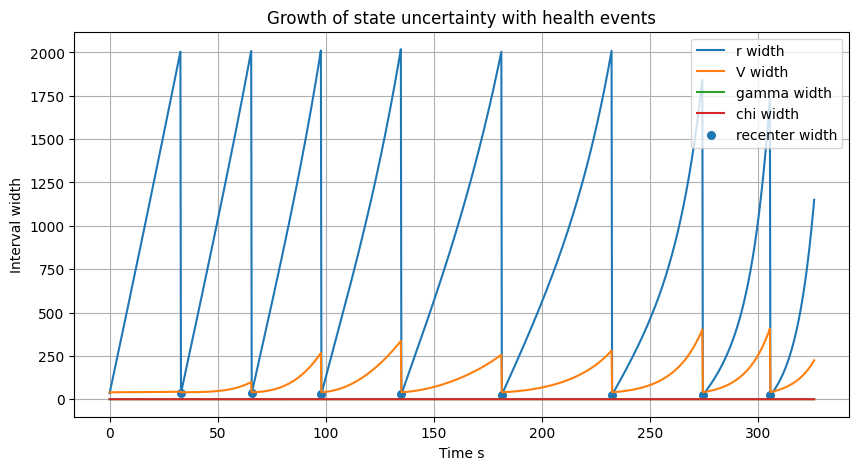

In [ ]:
# plot state widths and mark health intervention steps

active_df = df[df["interval_active"] == 1].copy()

if len(active_df) == 0:
    print("No active interval rows were logged")
else:
    plt.figure(figsize=(10, 5))
    plt.plot(active_df["t_s"], active_df["width_r_m"], label="r width")
    plt.plot(active_df["t_s"], active_df["width_V_mps"], label="V width")
    plt.plot(active_df["t_s"], active_df["width_gamma_rad"], label="gamma width")
    plt.plot(active_df["t_s"], active_df["width_chi_rad"], label="chi width")

    recenter_width_df = active_df[
        (active_df["interval_step_recentered"] == 1)
        & (active_df["interval_step_recenter_reason"] == "width_threshold")
    ]
    if len(recenter_width_df) > 0:
        plt.scatter(
            recenter_width_df["t_s"],
            recenter_width_df["width_r_m"],
            marker="o",
            s=30,
            label="recenter width",
        )

    split_width_df = active_df[
        (active_df["interval_step_split"] == 1)
        & (active_df["interval_step_split_reason"] == "width_threshold")
    ]
    if len(split_width_df) > 0:
        plt.scatter(
            split_width_df["t_s"],
            split_width_df["width_r_m"],
            marker="x",
            s=35,
            label="split width",
        )

    split_denom_df = active_df[
        (active_df["interval_step_split"] == 1)
        & (active_df["interval_step_split_reason"] != "width_threshold")
        & (active_df["interval_step_split_reason"] != "")
    ]
    if len(split_denom_df) > 0:
        plt.scatter(
            split_denom_df["t_s"],
            split_denom_df["width_r_m"],
            marker="^",
            s=35,
            label="split denominator",
        )

    if df["interval_failed"].max() > 0:
        t_fail = float(df[df["interval_failed"] == 1]["interval_failure_time_s"].iloc[0])
        plt.axvline(t_fail, linestyle="--", label="Interval failure time")

    plt.xlabel("Time s")
    plt.ylabel("Interval width")
    plt.title("Growth of state uncertainty with health events")
    plt.legend()
    plt.grid(True)
    plt.show()

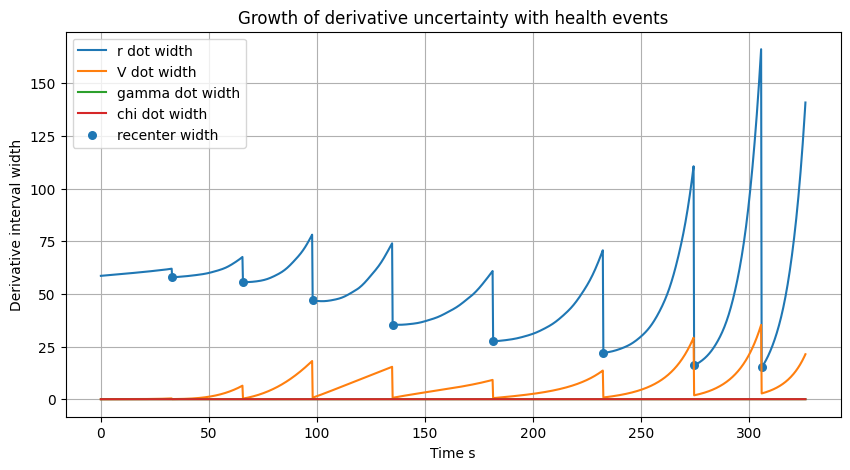

In [ ]:
# plot derivative widths and mark health intervention steps

active_df = df[df["interval_active"] == 1].copy()

if len(active_df) == 0:
    print("No active interval rows were logged")
else:
    plt.figure(figsize=(10, 5))
    plt.plot(active_df["t_s"], active_df["dx_width_r"], label="r dot width")
    plt.plot(active_df["t_s"], active_df["dx_width_V"], label="V dot width")
    plt.plot(active_df["t_s"], active_df["dx_width_gamma"], label="gamma dot width")
    plt.plot(active_df["t_s"], active_df["dx_width_chi"], label="chi dot width")

    recenter_width_df = active_df[
        (active_df["interval_step_recentered"] == 1)
        & (active_df["interval_step_recenter_reason"] == "width_threshold")
    ]
    if len(recenter_width_df) > 0:
        plt.scatter(
            recenter_width_df["t_s"],
            recenter_width_df["dx_width_r"],
            marker="o",
            s=30,
            label="recenter width",
        )

    split_width_df = active_df[
        (active_df["interval_step_split"] == 1)
        & (active_df["interval_step_split_reason"] == "width_threshold")
    ]
    if len(split_width_df) > 0:
        plt.scatter(
            split_width_df["t_s"],
            split_width_df["dx_width_r"],
            marker="x",
            s=35,
            label="split width",
        )

    split_denom_df = active_df[
        (active_df["interval_step_split"] == 1)
        & (active_df["interval_step_split_reason"] != "width_threshold")
        & (active_df["interval_step_split_reason"] != "")
    ]
    if len(split_denom_df) > 0:
        plt.scatter(
            split_denom_df["t_s"],
            split_denom_df["dx_width_r"],
            marker="^",
            s=35,
            label="split denominator",
        )

    if df["interval_failed"].max() > 0:
        t_fail = float(df[df["interval_failed"] == 1]["interval_failure_time_s"].iloc[0])
        plt.axvline(t_fail, linestyle="--", label="Interval failure time")

    plt.xlabel("Time s")
    plt.ylabel("Derivative interval width")
    plt.title("Growth of derivative uncertainty with health events")
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
# Quick interval status summary

print(df["safety_status"].value_counts(dropna=False))
print()
print(df["interval_failure_kind"].value_counts(dropna=False))


safety_status
inside    1305
Name: count, dtype: int64

interval_failure_kind
    1305
Name: count, dtype: int64


In [ ]:
# Show rows where the safety status is not fully inside

df[df["safety_status"] != "inside"][
    [
        "t_s",
        "alt_m",
        "V_mps",
        "q_pa",
        "interval_alt_lo",
        "interval_alt_hi",
        "interval_q_lo",
        "interval_q_hi",
        "safety_status",
        "safety_checks",
    ]
].head(20)

,t_s,alt_m,V_mps,q_pa,interval_alt_lo,interval_alt_hi,interval_q_lo,interval_q_hi,safety_status,safety_checks


### It means the propagated interval box now partly satisfies a limit and partly violates it. So within the uncertainty envelope, some possible states are still inside the allowed region and some are outside

In [ ]:
# Save outputs for later review

# Save the main success trajectory log
df.to_csv(success_trajectory_csv_path, index=False)
print("Saved", success_trajectory_csv_path)

# Save the failed heat step log for RL teaching
failed_heat_steps_df.to_csv(failed_heat_step_csv_path, index=False)
print("Saved", failed_heat_step_csv_path)

# Save the compact failed episode summary
failed_episode_summary_df.to_csv(failed_heat_episode_csv_path, index=False)
print("Saved", failed_heat_episode_csv_path)

# Also save a legacy named copy of the main log for compatibility
output_csv = "conditional_uncertainty_propagation_log.csv"
df.to_csv(output_csv, index=False)
print("Saved", output_csv)

Saved trajectory_success.csv
Saved trajectory_failed_heat_steps.csv
Saved trajectory_failed_heat_episodes.csv
Saved conditional_uncertainty_propagation_log.csv


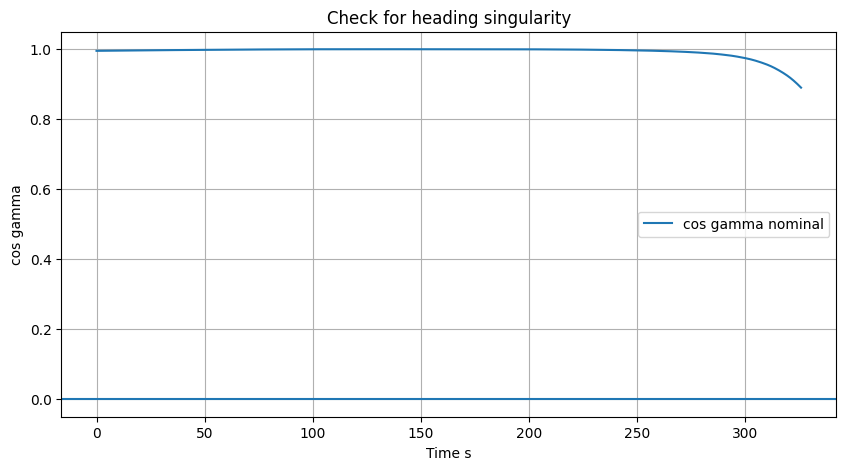

In [ ]:
# Check for heading singularity using the current logged gamma column

plt.figure(figsize=(10, 5))
plt.plot(df["t_s"], np.cos(df["gamma_rad"]), label="cos gamma nominal")
plt.axhline(0.0)
plt.xlabel("Time s")
plt.ylabel("cos gamma")
plt.title("Check for heading singularity")
plt.legend()
plt.grid(True)
plt.show()

# PLot Nominal and Interval Trajectory before blowup

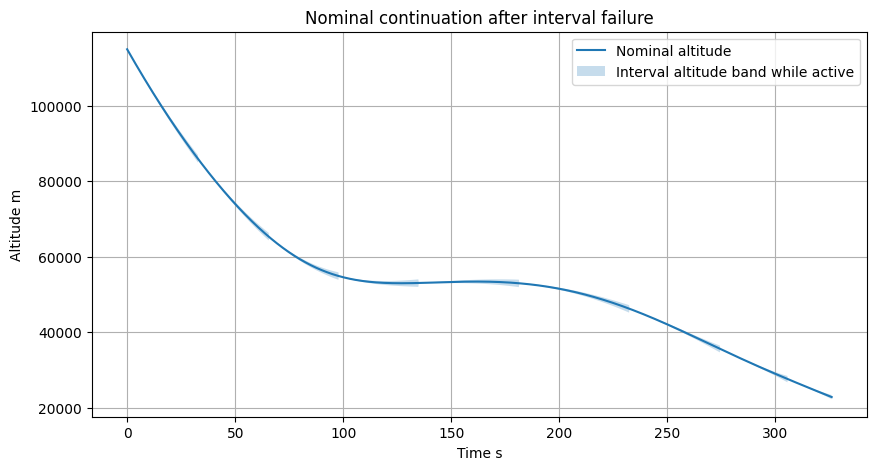

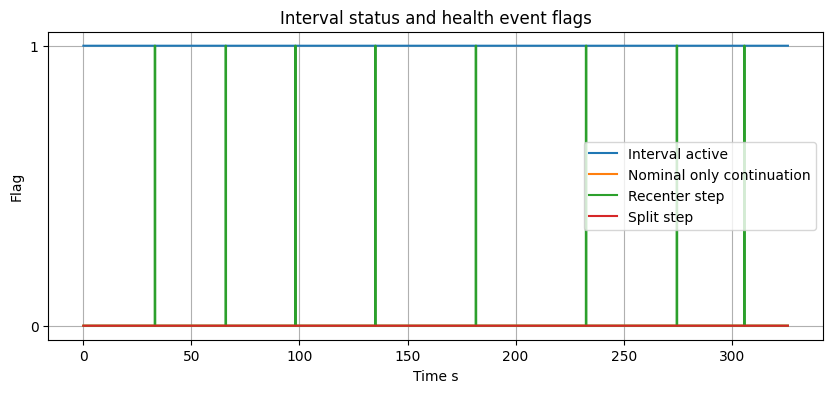

,t_s,interval_active,interval_failed,interval_step_recentered,interval_step_recenter_reason,interval_step_split,interval_step_split_reason,interval_step_split_depth,nominal_continued_after_interval_failure
132,33.00,1,0,1,width_threshold,0,,0,0
263,65.75,1,0,1,width_threshold,0,,0,0
392,98.00,1,0,1,width_threshold,0,,0,0
540,135.00,1,0,1,width_threshold,0,,0,0
726,181.50,1,0,1,width_threshold,0,,0,0
930,232.50,1,0,1,width_threshold,0,,0,0
1098,274.50,1,0,1,width_threshold,0,,0,0
1223,305.75,1,0,1,width_threshold,0,,0,0


In [ ]:
# plot interval activity and health event flags on one timeline

plt.figure(figsize=(10, 5))
plt.plot(df["t_s"], df["alt_m"], label="Nominal altitude")

active_df = df[df["interval_active"] == 1].copy()
if len(active_df) > 0:
    plt.fill_between(
        active_df["t_s"],
        active_df["interval_alt_lo"],
        active_df["interval_alt_hi"],
        alpha=0.25,
        label="Interval altitude band while active",
    )

if df["interval_failed"].max() > 0:
    t_fail = float(df[df["interval_failed"] == 1]["interval_failure_time_s"].iloc[0])
    plt.axvline(t_fail, linestyle="--", label="Interval failure time")

plt.xlabel("Time s")
plt.ylabel("Altitude m")
plt.title("Nominal continuation after interval failure")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.step(df["t_s"], df["interval_active"], where="post", label="Interval active")
plt.step(df["t_s"], df["nominal_continued_after_interval_failure"], where="post", label="Nominal only continuation")
plt.step(df["t_s"], df["interval_step_recentered"], where="post", label="Recenter step")
plt.step(df["t_s"], df["interval_step_split"], where="post", label="Split step")
plt.xlabel("Time s")
plt.ylabel("Flag")
plt.title("Interval status and health event flags")
plt.yticks([0, 1])
plt.legend()
plt.grid(True)
plt.show()

event_cols = [
    "t_s",
    "interval_active",
    "interval_failed",
    "interval_step_recentered",
    "interval_step_recenter_reason",
    "interval_step_split",
    "interval_step_split_reason",
    "interval_step_split_depth",
    "nominal_continued_after_interval_failure",
]

df[
    (df["interval_step_recentered"] == 1)
    | (df["interval_step_split"] == 1)
    | (df["interval_failed"] == 1)
][event_cols].head(25)

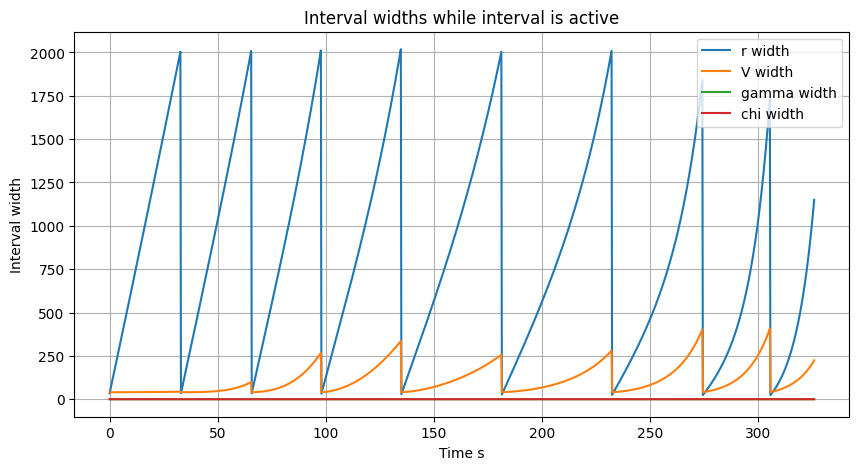

         t_s    width_r_m  width_V_mps  width_gamma_rad  width_chi_rad  \
1295  323.75   867.664619   181.119466         0.069019       0.084616   
1296  324.00   895.441369   185.436134         0.071549       0.087663   
1297  324.25   924.044116   189.867917         0.074192       0.090828   
1298  324.50   953.500252   194.418174         0.076954       0.094114   
1299  324.75   983.838117   199.090384         0.079842       0.097529   
1300  325.00  1015.087037   203.888128         0.082861       0.101079   
1301  325.25  1047.277367   208.815111         0.086019       0.104769   
1302  325.50  1080.440527   213.875168         0.089323       0.108608   
1303  325.75  1114.609052   219.072253         0.092780       0.112603   
1304  326.00  1149.816637   224.410458         0.096400       0.116763   

      interval_step_recentered interval_step_recenter_reason  \
1295                         0                                 
1296                         0                           

In [ ]:
# show interval widths while the interval layer is active

active_df = df[df["interval_active"] == 1].copy()

if len(active_df) == 0:
    print("No active interval rows were logged")
else:
    plt.figure(figsize=(10, 5))
    plt.plot(active_df["t_s"], active_df["width_r_m"], label="r width")
    plt.plot(active_df["t_s"], active_df["width_V_mps"], label="V width")
    plt.plot(active_df["t_s"], active_df["width_gamma_rad"], label="gamma width")
    plt.plot(active_df["t_s"], active_df["width_chi_rad"], label="chi width")
    plt.xlabel("Time s")
    plt.ylabel("Interval width")
    plt.title("Interval widths while interval is active")
    plt.legend()
    plt.grid(True)
    plt.show()

    print(
        active_df[
            [
                "t_s",
                "width_r_m",
                "width_V_mps",
                "width_gamma_rad",
                "width_chi_rad",
                "interval_step_recentered",
                "interval_step_recenter_reason",
                "interval_step_split",
                "interval_step_split_reason",
            ]
        ].tail(10)
    )

# Reaction Control System (RCS) analysis

In [ ]:
# Add degree based convenience columns for control diagnostics

df["sigma_cmd_deg"] = np.degrees(df["sigma_cmd_rad"])
df["sigma_target_deg"] = np.degrees(df["sigma_target_rad"])
df["sigma_actual_deg"] = np.degrees(df["sigma_actual_rad"])
df["roll_rate_deg_s"] = np.degrees(df["roll_rate_rad_s"])
df["roll_accel_deg_s2"] = np.degrees(df["roll_accel_rad_s2"])

df[
    [
        "t_s",
        "sigma_cmd_deg",
        "sigma_target_deg",
        "sigma_actual_deg",
        "roll_rate_deg_s",
        "tau_roll_cmd_Nm",
        "requested_duty",
        "fired_this_step",
        "active_thrusters",
        "torque_z_from_rcs",
    ]
].head(12)

,t_s,sigma_cmd_deg,sigma_target_deg,sigma_actual_deg,roll_rate_deg_s,tau_roll_cmd_Nm,requested_duty,fired_this_step,active_thrusters,torque_z_from_rcs
0,0.00,70.0,2.5,0.000000,0.000000,349.065850,0.061307,0,,0.000000
1,0.25,70.0,7.5,0.000000,0.000000,1047.197551,0.183921,0,,0.000000
2,0.50,70.0,12.5,0.194105,1.386462,1745.329252,0.306536,1,"POD0_RPOS,POD1_RPOS,POD2_RPOS,POD3_RPOS",1935.866047
3,0.75,70.0,17.5,0.720552,3.099150,2319.565526,0.407390,1,"POD0_RPOS,POD1_RPOS,POD2_RPOS,POD3_RPOS",2391.363940
4,1.00,70.0,22.5,1.692299,4.974952,2824.623057,0.496094,1,"POD0_RPOS,POD1_RPOS,POD2_RPOS,POD3_RPOS",2619.112887
5,1.25,70.0,27.5,3.181522,7.258536,3256.117678,0.571878,1,"POD0_RPOS,POD1_RPOS,POD2_RPOS,POD3_RPOS",3188.485254
6,1.50,70.0,32.5,5.274264,9.786790,3586.890328,0.629973,1,"POD0_RPOS,POD1_RPOS,POD2_RPOS,POD3_RPOS",3530.108674
7,1.75,70.0,37.5,8.007225,12.722827,3816.314697,0.670267,1,"POD0_RPOS,POD1_RPOS,POD2_RPOS,POD3_RPOS",4099.481041
8,2.00,70.0,42.5,11.430563,15.495751,3927.878985,0.689861,1,"POD0_RPOS,POD1_RPOS,POD2_RPOS,POD3_RPOS",3871.732094
9,2.25,70.0,47.5,15.554064,18.187118,3954.435980,0.694525,1,"POD0_RPOS,POD1_RPOS,POD2_RPOS,POD3_RPOS",3757.857621


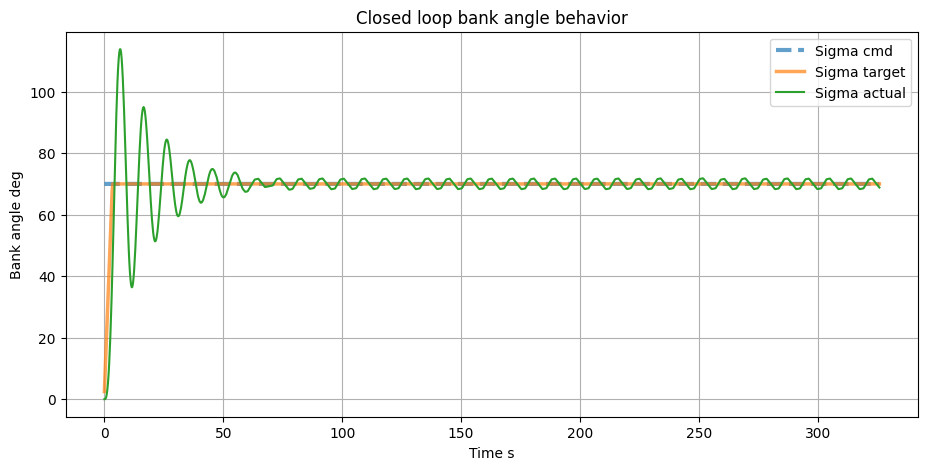

In [ ]:
# Initialize a new figure with specific dimensions for the plot
plt.figure(figsize=(11, 5))

# Plot the commanded bank angle with a dashed line and increased width to prevent it from being hidden
plt.plot(df["t_s"], df["sigma_cmd_deg"], label="Sigma cmd", linestyle="dashed", linewidth=3.0, alpha=0.7)

# Plot the smoothed target bank angle with a dotted line
plt.plot(df["t_s"], df["sigma_target_deg"], label="Sigma target", linewidth=2.5, alpha=0.7)

# Plot the actual flown bank angle with a standard solid line
plt.plot(df["t_s"], df["sigma_actual_deg"], label="Sigma actual", linewidth=1.5)

# Apply text labels to both the horizontal and vertical axes
plt.xlabel("Time s")
plt.ylabel("Bank angle deg")

# Set the main title for the graph
plt.title("Closed loop bank angle behavior")

# Insert a legend to clearly identify each variable
plt.legend()

# Enable the background grid for easier visual tracking of values
plt.grid(True)

# Render and display the completed plot
plt.show()

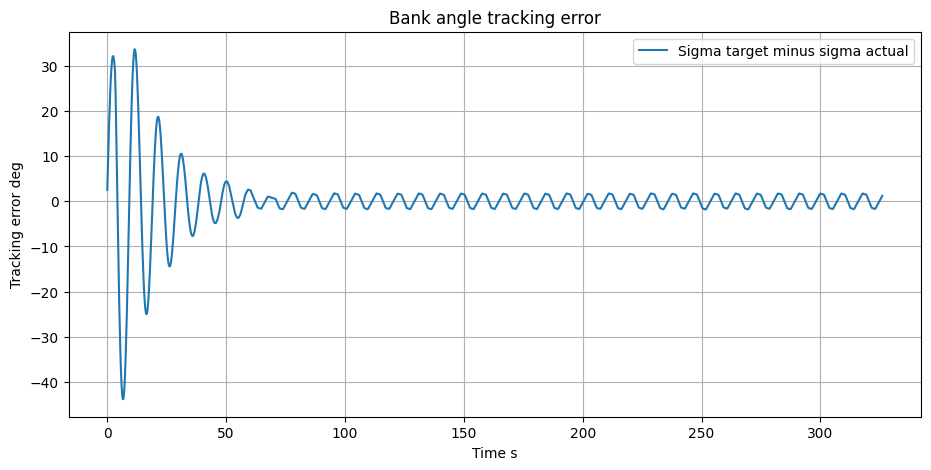

In [ ]:
# Plot actual bank tracking error

tracking_error_deg = df["sigma_target_deg"] - df["sigma_actual_deg"]

plt.figure(figsize=(11, 5))
plt.plot(df["t_s"], tracking_error_deg, label="Sigma target minus sigma actual")
plt.xlabel("Time s")
plt.ylabel("Tracking error deg")
plt.title("Bank angle tracking error")
plt.legend()
plt.grid(True)
plt.show()

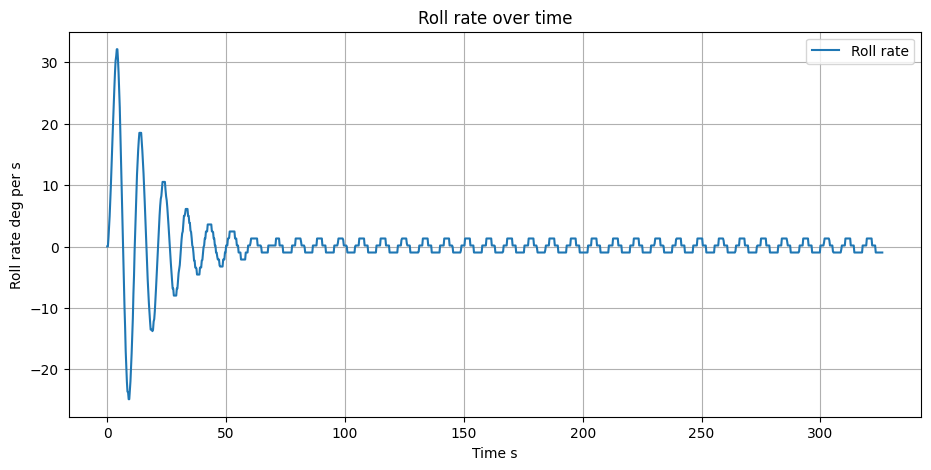

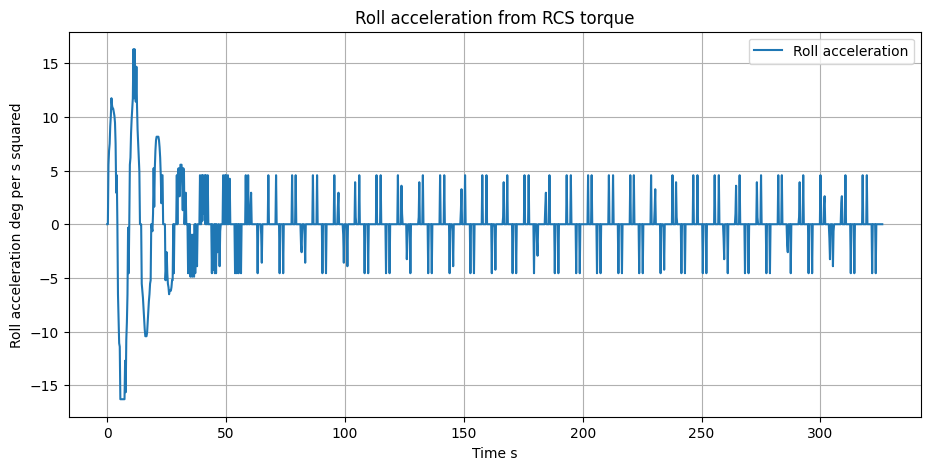

In [ ]:
# Plot roll rate and roll acceleration

plt.figure(figsize=(11, 5))
plt.plot(df["t_s"], df["roll_rate_deg_s"], label="Roll rate")
plt.xlabel("Time s")
plt.ylabel("Roll rate deg per s")
plt.title("Roll rate over time")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(11, 5))
plt.plot(df["t_s"], df["roll_accel_deg_s2"], label="Roll acceleration")
plt.xlabel("Time s")
plt.ylabel("Roll acceleration deg per s squared")
plt.title("Roll acceleration from RCS torque")
plt.legend()
plt.grid(True)
plt.show()

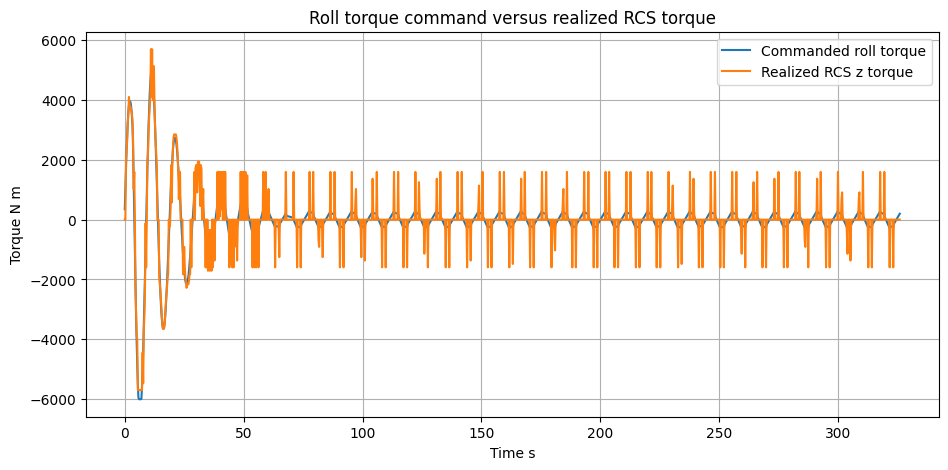

In [ ]:
# Plot commanded roll torque and realized RCS roll torque

plt.figure(figsize=(11, 5))
plt.plot(df["t_s"], df["tau_roll_cmd_Nm"], label="Commanded roll torque")
plt.plot(df["t_s"], df["torque_z_from_rcs"], label="Realized RCS z torque")
plt.xlabel("Time s")
plt.ylabel("Torque N m")
plt.title("Roll torque command versus realized RCS torque")
plt.legend()
plt.grid(True)
plt.show()

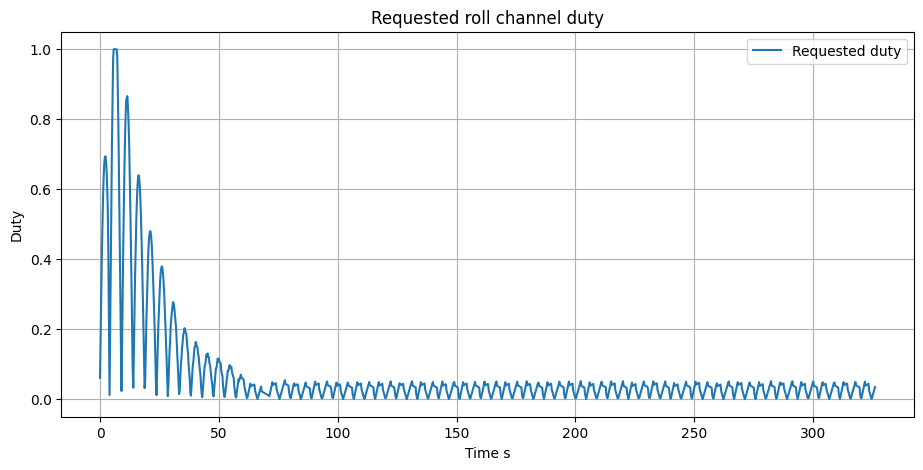

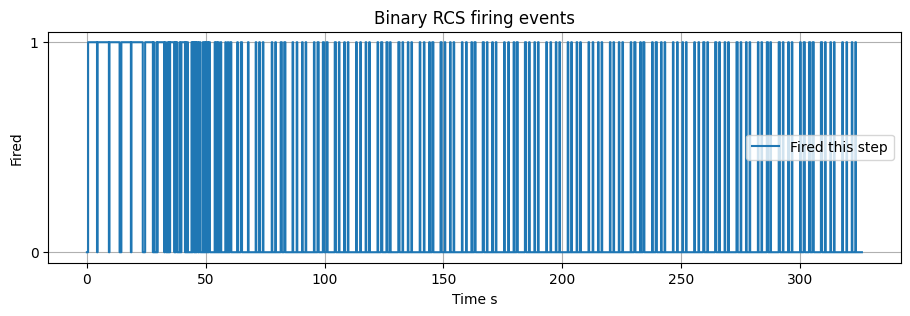

In [ ]:
# Plot requested duty and whether a firing actually happened this step

plt.figure(figsize=(11, 5))
plt.plot(df["t_s"], df["requested_duty"], label="Requested duty")
plt.xlabel("Time s")
plt.ylabel("Duty")
plt.title("Requested roll channel duty")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(11, 3))
plt.step(df["t_s"], df["fired_this_step"], where="post", label="Fired this step")
plt.xlabel("Time s")
plt.ylabel("Fired")
plt.title("Binary RCS firing events")
plt.yticks([0, 1])
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Expand active thrusters into one row per thruster firing event

# Build a flat event table so each individual thruster firing can be analyzed on its own row
thruster_event_rows = []

# Walk through the trajectory log row by row to inspect which thrusters were active at each time step
for _, row in df.iterrows():
    # Read the raw active thruster field for this time step
    active_str = row["active_thrusters"]

    # Skip rows where no thruster activity was logged
    if pd.isna(active_str):
        continue

    # Clean up whitespace so empty strings do not get treated as valid activity
    active_str = str(active_str).strip()

    # Skip rows where the field exists but contains no actual thruster names
    if active_str == "":
        continue

    # Split the comma separated thruster list into individual thruster names
    active_list = [name.strip() for name in active_str.split(",") if name.strip()]

    # Create one output row per active thruster so each firing becomes its own event record
    for thr_name in active_list:
        thruster_event_rows.append(
            {
                # Save the simulation time of this firing event
                "t_s": float(row["t_s"]),

                # Save the specific thruster name that was active
                "thruster": thr_name,

                # Keep the requested duty value to compare command strength against actual firing behavior
                "requested_duty": float(row["requested_duty"]),

                # Keep the commanded roll torque so each firing can be tied back to the controller demand
                "tau_roll_cmd_Nm": float(row["tau_roll_cmd_Nm"]),

                # Keep the actual roll axis torque generated by the RCS system at this step
                "torque_z_from_rcs": float(row["torque_z_from_rcs"]),
            }
        )

# Convert the collected event records into a dataframe for inspection and plotting
thruster_events_df = pd.DataFrame(thruster_event_rows)

# Print the number of individual firing events extracted from the original log
print("Number of thruster firing records", len(thruster_events_df))

# Show the first several event rows to verify the expansion worked as expected
thruster_events_df.head(20)

Number of thruster firing records 1220


,t_s,thruster,requested_duty,tau_roll_cmd_Nm,torque_z_from_rcs
0,0.50,POD0_RPOS,0.306536,1745.329252,1935.866047
1,0.50,POD1_RPOS,0.306536,1745.329252,1935.866047
2,0.50,POD2_RPOS,0.306536,1745.329252,1935.866047
3,0.50,POD3_RPOS,0.306536,1745.329252,1935.866047
4,0.75,POD0_RPOS,0.407390,2319.565526,2391.363940
5,0.75,POD1_RPOS,0.407390,2319.565526,2391.363940
6,0.75,POD2_RPOS,0.407390,2319.565526,2391.363940
7,0.75,POD3_RPOS,0.407390,2319.565526,2391.363940
8,1.00,POD0_RPOS,0.496094,2824.623057,2619.112887
9,1.00,POD1_RPOS,0.496094,2824.623057,2619.112887


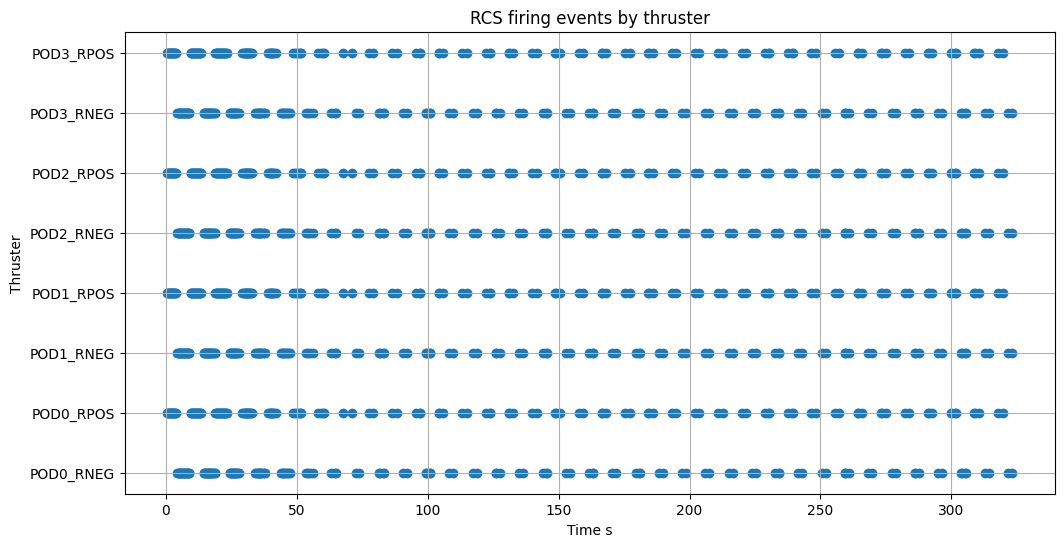

In [ ]:
# Scatter plot of which thrusters fired and when

if len(thruster_events_df) == 0:
    print("No thruster firing events were logged")
else:
    thruster_names = sorted(thruster_events_df["thruster"].unique())
    thruster_to_y = {name: idx for idx, name in enumerate(thruster_names)}

    y_vals = thruster_events_df["thruster"].map(thruster_to_y)

    plt.figure(figsize=(12, 6))
    plt.scatter(thruster_events_df["t_s"], y_vals)
    plt.xlabel("Time s")
    plt.ylabel("Thruster")
    plt.title("RCS firing events by thruster")
    plt.yticks(list(thruster_to_y.values()), list(thruster_to_y.keys()))
    plt.grid(True)
    plt.show()

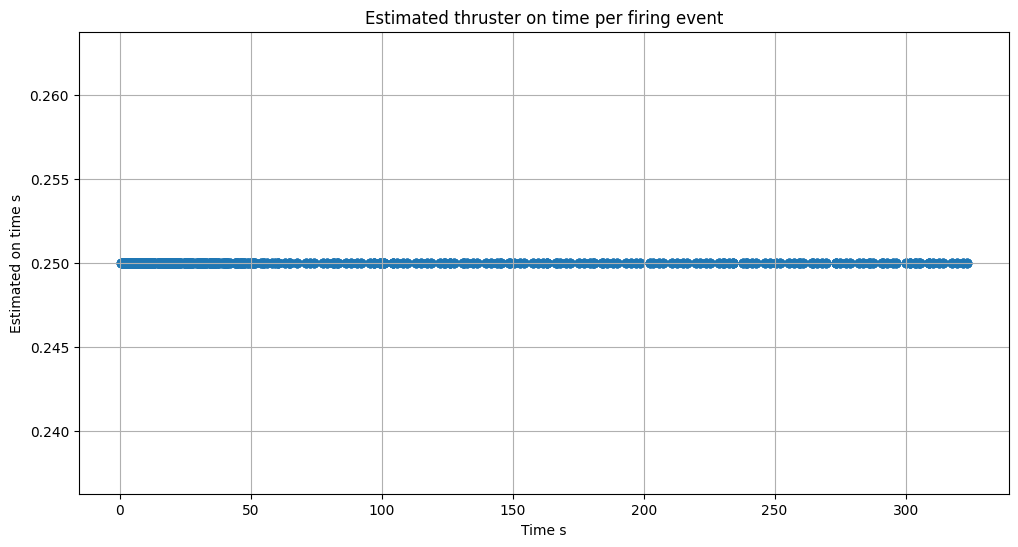

In [ ]:
# Estimated on time per active thruster during each step

# This is estimated on time per active thruster during the step.
# In this milestone 1 model, a firing step means the channel fired for the full dt.
# The requested duty still shows the fractional demand before pulse accumulation.

if len(thruster_events_df) == 0:
    print("No thruster firing events were logged")
else:
    thruster_events_df["estimated_on_time_s"] = dt_s

    plt.figure(figsize=(12, 6))
    plt.scatter(
        thruster_events_df["t_s"],
        thruster_events_df["estimated_on_time_s"],
    )
    plt.xlabel("Time s")
    plt.ylabel("Estimated on time s")
    plt.title("Estimated thruster on time per firing event")
    plt.grid(True)
    plt.show()

##  Requested duty versus actual firing events
## Duty = is the fraction of full roll-channel capability the controller is requesting at that moment

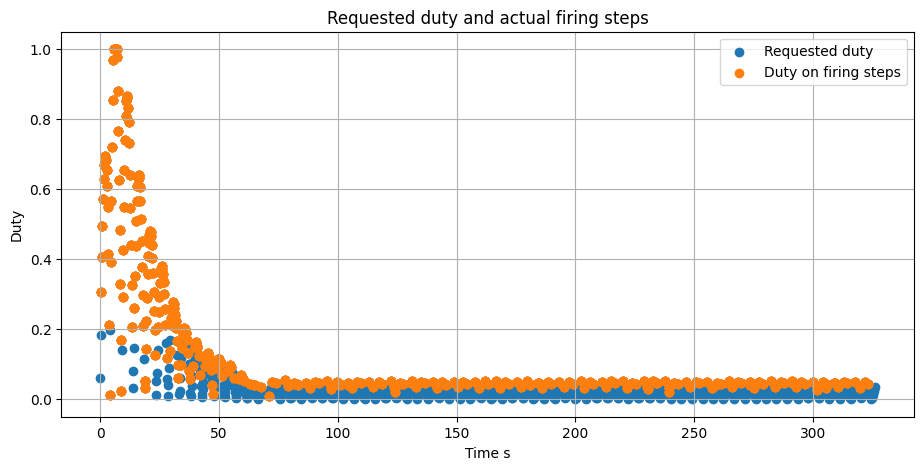

In [ ]:
# Requested duty versus actual firing events

if len(thruster_events_df) == 0:
    print("No thruster firing events were logged")
else:
    plt.figure(figsize=(11, 5))
    plt.scatter(df["t_s"], df["requested_duty"], label="Requested duty")
    plt.scatter(
        thruster_events_df["t_s"],
        thruster_events_df["requested_duty"],
        label="Duty on firing steps",
    )
    plt.xlabel("Time s")
    plt.ylabel("Duty")
    plt.title("Requested duty and actual firing steps")
    plt.legend()
    plt.grid(True)
    plt.show()

### The system converts continuous demand into discrete pulses
#### This graph shows how continuous roll torque demand is converted into discrete full-power RCS pulses over time, with firing frequency decreasing as the system stabilizes.
### System demands fractional pulse (i.e 0.3 of a pulse right now)
### But the system can only do 0 or 1 full pulse
### So it waits and accumulates until it has enough (>= 1), then fires

# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Rolling summary of firing frequency

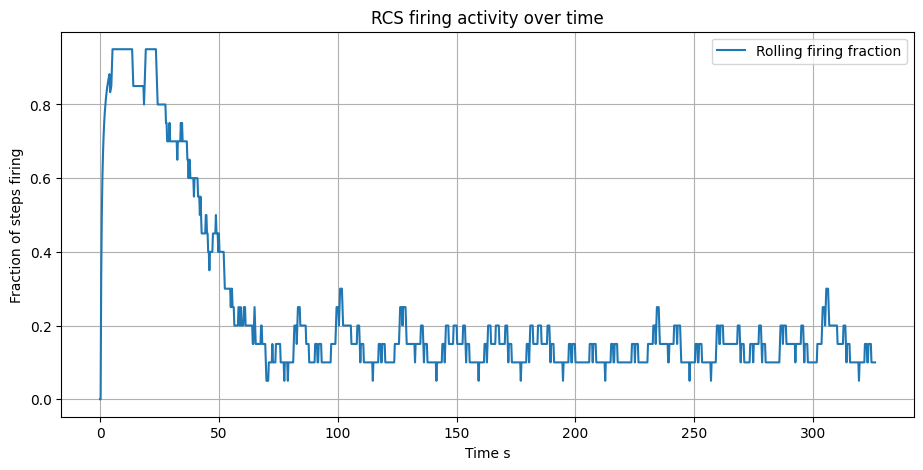

In [ ]:
# Rolling summary of firing frequency

window_steps = 20

df["firing_rate_window"] = df["fired_this_step"].rolling(window_steps, min_periods=1).mean()

plt.figure(figsize=(11, 5))
plt.plot(df["t_s"], df["firing_rate_window"], label="Rolling firing fraction")
plt.xlabel("Time s")
plt.ylabel("Fraction of steps firing")
plt.title("RCS firing activity over time")
plt.legend()
plt.grid(True)
plt.show()

## final compact view

In [ ]:
# final compact view with interval health semantics

summary_cols = [
    "t_s",
    "alt_m",
    "V_mps",
    "gamma_rad",
    "sigma_actual_deg",
    "interval_active",
    "interval_failed",
    "interval_failure_kind",
    "interval_step_recentered",
    "interval_step_recenter_reason",
    "interval_step_split",
    "interval_step_split_reason",
    "interval_step_split_depth",
    "nominal_continued_after_interval_failure",
    "nominal_heat_qdot_max_hi",
    "nominal_heat_Q_max_hi",
    "width_r_m",
    "width_V_mps",
    "width_gamma_rad",
    "width_chi_rad",
    "interval_rho_lo",
    "interval_rho_hi",
    "interval_q_lo",
    "interval_q_hi",
    "heating_qdot_max_hi",
    "safety_status",
]

summary_df = df[summary_cols].copy()
summary_df["gamma_deg"] = np.degrees(summary_df["gamma_rad"])

summary_df[
    [
        "t_s",
        "alt_m",
        "V_mps",
        "gamma_deg",
        "sigma_actual_deg",
        "interval_active",
        "interval_failed",
        "interval_failure_kind",
        "interval_step_recentered",
        "interval_step_recenter_reason",
        "interval_step_split",
        "interval_step_split_reason",
        "interval_step_split_depth",
        "nominal_continued_after_interval_failure",
        "nominal_heat_qdot_max_hi",
        "nominal_heat_Q_max_hi",
        "width_r_m",
        "width_V_mps",
        "width_gamma_rad",
        "width_chi_rad",
        "interval_rho_lo",
        "interval_rho_hi",
        "interval_q_lo",
        "interval_q_hi",
        "heating_qdot_max_hi",
        "safety_status",
    ]
].tail(15)

,t_s,alt_m,V_mps,gamma_deg,sigma_actual_deg,interval_active,interval_failed,interval_failure_kind,interval_step_recentered,interval_step_recenter_reason,...,width_r_m,width_V_mps,width_gamma_rad,width_chi_rad,interval_rho_lo,interval_rho_hi,interval_q_lo,interval_q_hi,heating_qdot_max_hi,safety_status
1290,322.50,23633.577423,557.506760,-24.411580,71.637264,1,0,,0,,...,740.275540,161.152522,0.057882,0.070963,0.047353,0.053422,5397.850638,10768.480283,10150.331671,inside
1291,322.75,23575.974644,553.313414,-24.597019,71.678043,1,0,,0,,...,764.301128,164.940389,0.059932,0.073494,0.047721,0.054055,5299.290071,10809.835781,10089.298884,inside
1292,323.00,23518.397750,549.155871,-24.783864,71.718821,1,0,,0,,...,789.029914,168.828123,0.062060,0.076123,0.048090,0.054699,5199.934474,10854.318548,10032.067079,inside
1293,323.25,23460.846707,545.033921,-24.972116,71.516968,1,0,,0,,...,814.484070,172.818562,0.064280,0.078850,0.048458,0.055355,5099.780435,10902.039708,9978.655218,inside
1294,323.50,23403.321491,540.947357,-25.161249,71.272299,1,0,,0,,...,840.687386,176.914661,0.066598,0.081680,0.048827,0.056023,4998.815107,10953.119713,9929.087209,inside
1295,323.75,23345.823219,536.895946,-25.351170,71.027629,1,0,,0,,...,867.664619,181.119466,0.069019,0.084616,0.049195,0.056703,4897.028774,11007.667897,9883.382493,inside
1296,324.00,23288.353190,532.879454,-25.541879,70.782959,1,0,,0,,...,895.441369,185.436134,0.071549,0.087663,0.049564,0.057396,4794.412274,11065.824407,9841.575310,inside
1297,324.25,23230.912688,528.897665,-25.733375,70.538289,1,0,,0,,...,924.044116,189.867917,0.074192,0.090828,0.049931,0.058101,4690.957765,11127.715345,9803.694474,inside
1298,324.50,23173.502977,524.950339,-25.925658,70.293620,1,0,,0,,...,953.500252,194.418174,0.076954,0.094114,0.050298,0.058821,4586.659212,11193.476980,9769.774359,inside
1299,324.75,23116.125304,521.037243,-26.118726,70.048950,1,0,,0,,...,983.838117,199.090384,0.079842,0.097529,0.050665,0.059554,4481.510904,11263.268462,9739.860292,inside


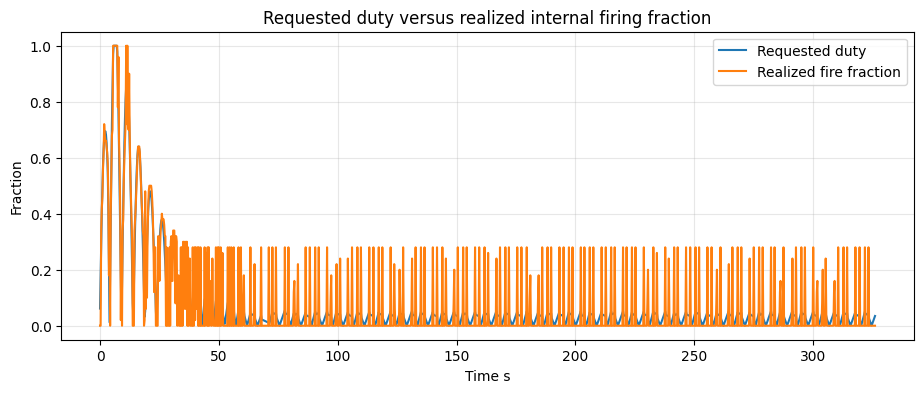

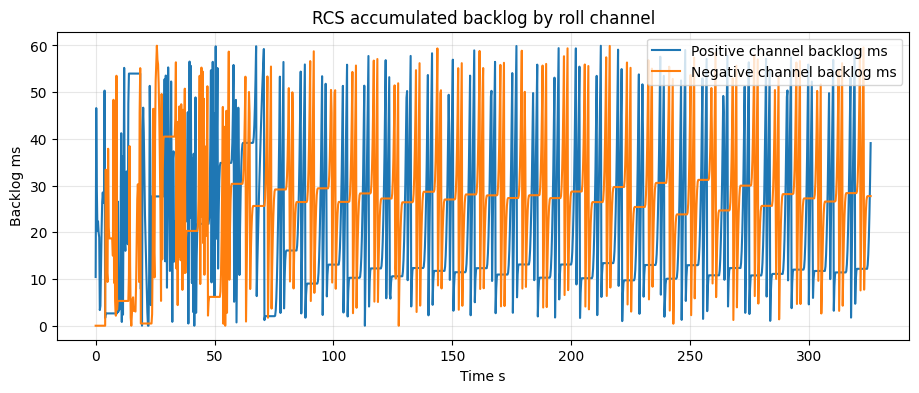

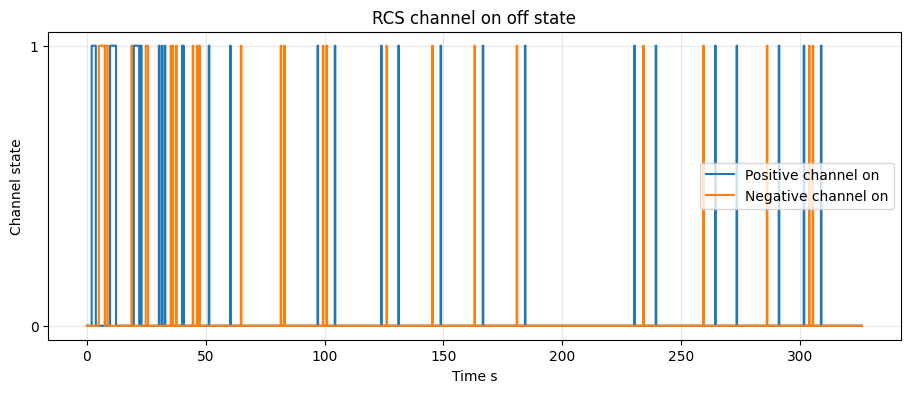

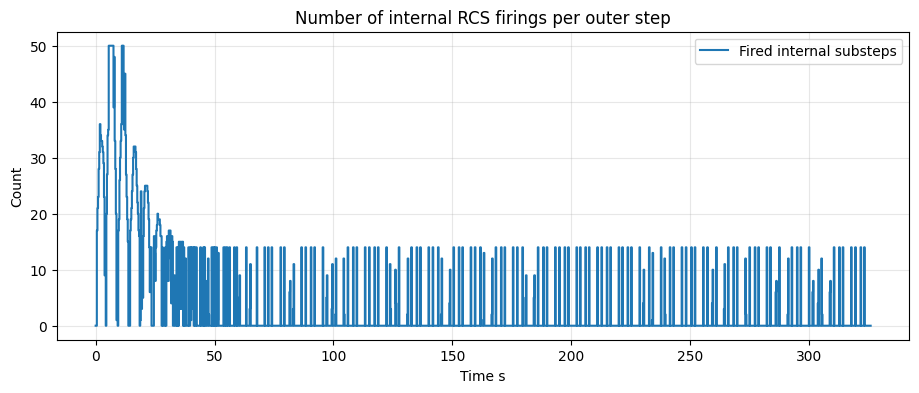

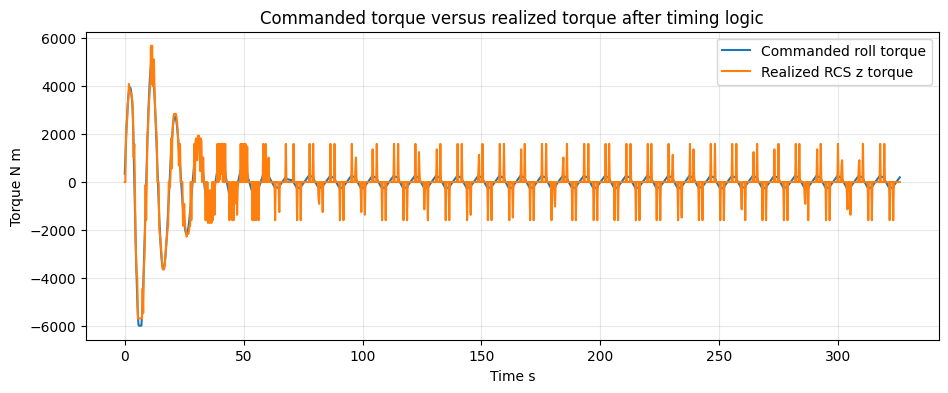

In [ ]:
# Plot RCS timing behavior from the logged dataframe

rcs_plot_df = df.copy()

# Realized fired fraction over the outer step
# This shows how many internal substeps actually fired
if "num_fired_internal_steps" in rcs_plot_df.columns and "num_internal_steps" in rcs_plot_df.columns:
    rcs_plot_df["realized_fire_fraction"] = (
        rcs_plot_df["num_fired_internal_steps"] / rcs_plot_df["num_internal_steps"].replace(0, np.nan)
    )
else:
    rcs_plot_df["realized_fire_fraction"] = np.nan

# Convert backlog from seconds to milliseconds for easier reading
if "roll_pos_backlog_s" in rcs_plot_df.columns:
    rcs_plot_df["roll_pos_backlog_ms"] = 1000.0 * rcs_plot_df["roll_pos_backlog_s"]

if "roll_neg_backlog_s" in rcs_plot_df.columns:
    rcs_plot_df["roll_neg_backlog_ms"] = 1000.0 * rcs_plot_df["roll_neg_backlog_s"]

# Requested duty versus realized fired fraction
plt.figure(figsize=(11, 4))
plt.plot(rcs_plot_df["t_s"], rcs_plot_df["requested_duty"], label="Requested duty")
plt.plot(rcs_plot_df["t_s"], rcs_plot_df["realized_fire_fraction"], label="Realized fire fraction")
plt.xlabel("Time s")
plt.ylabel("Fraction")
plt.title("Requested duty versus realized internal firing fraction")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Positive and negative channel backlog
plt.figure(figsize=(11, 4))
if "roll_pos_backlog_ms" in rcs_plot_df.columns:
    plt.plot(rcs_plot_df["t_s"], rcs_plot_df["roll_pos_backlog_ms"], label="Positive channel backlog ms")
if "roll_neg_backlog_ms" in rcs_plot_df.columns:
    plt.plot(rcs_plot_df["t_s"], rcs_plot_df["roll_neg_backlog_ms"], label="Negative channel backlog ms")
plt.xlabel("Time s")
plt.ylabel("Backlog ms")
plt.title("RCS accumulated backlog by roll channel")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Positive and negative channel on off state
plt.figure(figsize=(11, 4))
if "roll_pos_is_on" in rcs_plot_df.columns:
    plt.step(rcs_plot_df["t_s"], rcs_plot_df["roll_pos_is_on"], where="post", label="Positive channel on")
if "roll_neg_is_on" in rcs_plot_df.columns:
    plt.step(rcs_plot_df["t_s"], rcs_plot_df["roll_neg_is_on"], where="post", label="Negative channel on")
plt.xlabel("Time s")
plt.ylabel("Channel state")
plt.title("RCS channel on off state")
plt.yticks([0, 1])
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Number of fired internal substeps inside each outer step
plt.figure(figsize=(11, 4))
if "num_fired_internal_steps" in rcs_plot_df.columns:
    plt.step(
        rcs_plot_df["t_s"],
        rcs_plot_df["num_fired_internal_steps"],
        where="post",
        label="Fired internal substeps",
    )
plt.xlabel("Time s")
plt.ylabel("Count")
plt.title("Number of internal RCS firings per outer step")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Torque command and realized torque with timing context
plt.figure(figsize=(11, 4))
plt.plot(rcs_plot_df["t_s"], rcs_plot_df["tau_roll_cmd_Nm"], label="Commanded roll torque")
plt.plot(rcs_plot_df["t_s"], rcs_plot_df["torque_z_from_rcs"], label="Realized RCS z torque")
plt.xlabel("Time s")
plt.ylabel("Torque N m")
plt.title("Commanded torque versus realized torque after timing logic")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## Trajectory Visualization
Plotting the trajectory in 3D and 2D ground track.

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# 3D Capsule Motion
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

r = df['nom_r_m']
phi = df['nom_phi_rad']
lam = df['nom_lam_rad']

x = r * np.cos(phi) * np.cos(lam)
y = r * np.cos(phi) * np.sin(lam)
z = r * np.sin(phi)

ax.plot(x, y, z, label='Capsule Trajectory', color='red', linewidth=2)

# Draw Earth sphere for reference
u, v = np.mgrid[0:2*np.pi:50j, 0:np.pi:50j]
ex = constants.RADIUS_EARTH * np.cos(u) * np.sin(v)
ey = constants.RADIUS_EARTH * np.sin(u) * np.sin(v)
ez = constants.RADIUS_EARTH * np.cos(v)
ax.plot_surface(ex, ey, ez, color='blue', alpha=0.1, edgecolor='none')

ax.set_title('Capsule Motion in 3D')
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_zlabel('Z (m)')
ax.legend()
plt.show()


In [ ]:
# Ground Track (Lat/Lon)
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(np.degrees(df['nom_lam_rad']), np.degrees(df['nom_phi_rad']), label='Ground Track', color='blue')
ax.scatter(np.degrees(df['nom_lam_rad'].iloc[0]), np.degrees(df['nom_phi_rad'].iloc[0]), color='green', label='Start', zorder=5)
ax.scatter(np.degrees(df['nom_lam_rad'].iloc[-1]), np.degrees(df['nom_phi_rad'].iloc[-1]), color='red', label='End', zorder=5)
ax.scatter(np.degrees(target_lam_rad), np.degrees(target_phi_rad), color='orange', marker='X', s=100, label='Target', zorder=5)

ax.set_xlabel('Longitude (deg)')
ax.set_ylabel('Latitude (deg)')
ax.set_title('Trajectory Ground Track')
ax.grid(True)
ax.legend()
plt.show()
